# Pedagogical Label Analysis

This notebook compares human rubric ratings in `data/` with LLM ratings in `Clean output/`.

**Rubric dimensions analyzed (available in this repo snapshot):**
- `coherence`
- `signaling`
- `label_accuracy`
- `labeling`

Human consensus is built from `data/human_ratings.json` and shared-diagram disagreement resolution in `data/qc_adjudications.json`.

In [1]:
import json
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 120)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

In [2]:
ROOT = Path(".")
DATA_DIR = ROOT / "data"
CLEAN_DIR = ROOT / "Clean output"
PLOT_DIR = ROOT / "analysis_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DIMENSIONS = ["coherence", "signaling", "label_accuracy", "labeling"]
LABEL_ORDER = ["Yes", "No", "N/A"]

LABEL_COLORS = {
    "Yes": "#2ca25f",
    "No": "#de2d26",
    "N/A": "#636363",
}

MODEL_FILES = {
    "gpt-5.4": CLEAN_DIR / "pedagogical_eval_20260311_104845_798292.json",
    "claude-sonnet-4-6": CLEAN_DIR / "pedagogical_eval_20260311_112236_804750.json",
    "gemini-3.1-pro-preview": CLEAN_DIR / "gemini_pedagogical_eval_merged.json",
}

ENSEMBLE_MODEL_NAME = "ensemble_majority"
MODEL_DISPLAY_NAMES = {
    ENSEMBLE_MODEL_NAME: "ensemble_majority",
    "claude-sonnet-4-6": "claude-sonnet-4-6",
    "gemini-3.1-pro-preview": "gemini-3.1-pro",
    "gpt-5.4": "gpt-5.4",
}


def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def normalize_label(value):
    if value is None:
        return np.nan
    if isinstance(value, float) and np.isnan(value):
        return np.nan

    text = str(value).strip()
    if not text:
        return np.nan

    cleaned = text.upper().replace(" ", "")
    if cleaned in {"YES", "Y"}:
        return "Yes"
    if cleaned in {"NO", "N"}:
        return "No"
    if cleaned in {"N/A", "NA", "NOTAPPLICABLE", "NOTAPPLICABILE"}:
        return "N/A"

    return text


def majority_vote_label(values):
    """Return a strict majority label (>=2 votes), else NaN."""
    votes = [v for v in values if v in LABEL_ORDER]
    if not votes:
        return np.nan, "missing"

    counts = pd.Series(votes).value_counts()
    top_count = int(counts.iloc[0])
    tied = counts[counts == top_count].index.tolist()

    if top_count >= 2 and len(tied) == 1:
        return tied[0], "majority"
    return np.nan, "no_majority"


def extract_llm_rows(records, model_name):
    rows = []
    for rec in records:
        if not isinstance(rec, dict):
            continue
        diagram_id = str(rec.get("diagram_id", "")).strip()
        rubric = rec.get("rubric")
        if not diagram_id or not isinstance(rubric, dict):
            continue

        for dim in DIMENSIONS:
            payload = rubric.get(dim)
            if not isinstance(payload, dict):
                continue
            value = normalize_label(payload.get("value"))
            if value not in LABEL_ORDER:
                continue
            rows.append(
                {
                    "diagram_id": diagram_id,
                    "model": model_name,
                    "dimension": dim,
                    "value": value,
                }
            )
    return pd.DataFrame(rows)


def cohens_kappa(y_true, y_pred, labels):
    y_true = list(y_true)
    y_pred = list(y_pred)
    n = len(y_true)
    if n == 0:
        return np.nan

    table = pd.crosstab(
        pd.Categorical(y_true, categories=labels),
        pd.Categorical(y_pred, categories=labels),
        dropna=False,
    ).reindex(index=labels, columns=labels, fill_value=0)

    observed = np.trace(table.values) / n
    row_marginals = table.sum(axis=1).to_numpy(dtype=float) / n
    col_marginals = table.sum(axis=0).to_numpy(dtype=float) / n
    expected = float(np.dot(row_marginals, col_marginals))

    if np.isclose(1.0 - expected, 0.0):
        return np.nan
    return (observed - expected) / (1.0 - expected)


def savefig(fig, path: Path, dpi=150):
    """Save a matplotlib figure and display it inline."""
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def plot_stacked_bar(count_df, title, colors):
    """Stacked bar chart. count_df: index=dimensions, columns=labels."""
    count_df = count_df.copy()
    labels = list(count_df.columns)
    categories = list(count_df.index)
    x = np.arange(len(categories))

    fig, ax = plt.subplots(figsize=(7, 4))
    bottom = np.zeros(len(categories))
    for label in labels:
        vals = count_df[label].to_numpy(dtype=float)
        ax.bar(x, vals, bottom=bottom, width=0.55,
               color=colors.get(label, "#888"), label=label,
               edgecolor="white", linewidth=0.6)
        bottom += vals

    for i, (_, row) in enumerate(count_df.iterrows()):
        total = row.sum()
        ax.text(i, total + ax.get_ylim()[1] * 0.01, str(int(total)),
                ha="center", va="bottom", fontsize=9, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.legend(framealpha=0.9, fontsize=10)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e0e0e0", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig


In [3]:
human_raw = pd.DataFrame(load_json(DATA_DIR / "human_ratings.json"))
qc_shared = pd.DataFrame(load_json(DATA_DIR / "qc_adjudications.json"))

human_long = (
    human_raw.rename(columns={"original_csv_index": "diagram_id"})
    [["diagram_id", "rater", *DIMENSIONS]]
    .assign(diagram_id=lambda d: d["diagram_id"].astype(str))
    .melt(
        id_vars=["diagram_id", "rater"],
        value_vars=DIMENSIONS,
        var_name="dimension",
        value_name="value",
    )
)
human_long["value"] = human_long["value"].map(normalize_label)
human_long = human_long[human_long["value"].isin(LABEL_ORDER)].copy()

qc_lookup = {}
if not qc_shared.empty:
    qc_shared = qc_shared.copy()
    qc_shared["diagram_id"] = qc_shared["original_csv_index"].astype(str)
    qc_shared["qc_final_value"] = qc_shared["qc_final_value"].map(normalize_label)
    for row in qc_shared.itertuples(index=False):
        if row.qc_final_value in LABEL_ORDER:
            qc_lookup[(str(row.diagram_id), row.dimension)] = row.qc_final_value


def resolve_human_group(group):
    values = [v for v in group["value"].tolist() if v in LABEL_ORDER]
    unique = set(values)
    if len(unique) == 1:
        return values[0], "direct"

    key = (group.name[0], group.name[1])
    if key in qc_lookup:
        return qc_lookup[key], "qc_adjudication"

    if not values:
        return np.nan, "missing"

    counts = pd.Series(values).value_counts()
    top_count = counts.iloc[0]
    tied = counts[counts == top_count].index.tolist()
    for label in LABEL_ORDER:
        if label in tied:
            return label, "majority_tiebreak"
    return tied[0], "majority_tiebreak"


consensus_rows = []
for (diagram_id, dimension), group in human_long.groupby(["diagram_id", "dimension"]):
    value, resolution = resolve_human_group(group)
    if value in LABEL_ORDER:
        consensus_rows.append(
            {
                "diagram_id": diagram_id,
                "dimension": dimension,
                "value": value,
                "resolution": resolution,
            }
        )

human_consensus = pd.DataFrame(consensus_rows)

llm_frames = []
for model_name, path in MODEL_FILES.items():
    records = load_json(path)
    llm_frames.append(extract_llm_rows(records, model_name))
llm_long = pd.concat(llm_frames, ignore_index=True)

ensemble_rows = []
ensemble_resolution_rows = []
for (diagram_id, dimension), group in llm_long.groupby(["diagram_id", "dimension"]):
    voted_label, resolution = majority_vote_label(group["value"].tolist())
    ensemble_resolution_rows.append(
        {
            "diagram_id": diagram_id,
            "dimension": dimension,
            "n_model_votes": group["model"].nunique(),
            "resolution": resolution,
        }
    )
    if voted_label in LABEL_ORDER:
        ensemble_rows.append(
            {
                "diagram_id": diagram_id,
                "model": ENSEMBLE_MODEL_NAME,
                "dimension": dimension,
                "value": voted_label,
            }
        )

ensemble_long = pd.DataFrame(ensemble_rows)
if ensemble_long.empty:
    ensemble_long = pd.DataFrame(columns=["diagram_id", "model", "dimension", "value"])

llm_eval_long = pd.concat([llm_long, ensemble_long], ignore_index=True)
ensemble_resolution_df = pd.DataFrame(ensemble_resolution_rows)

human_ids = set(human_consensus["diagram_id"].unique())
overlap_rows = []
for model_name, g in llm_eval_long.groupby("model"):
    ids = set(g["diagram_id"].unique())
    overlap_rows.append(
        {
            "model": model_name,
            "llm_rows": len(g),
            "llm_unique_diagrams": len(ids),
            "overlap_with_human_diagrams": len(ids & human_ids),
            "diagrams_missing_vs_human": len(human_ids - ids),
        }
    )

print("Human raw rows:", len(human_raw))
print("Human long rows:", len(human_long))
print("Human consensus rows:", len(human_consensus))
print("Unique human diagrams:", human_consensus["diagram_id"].nunique())
print("Resolution method counts:")
print(human_consensus["resolution"].value_counts())
print("\nEnsemble vote resolution counts:")
print(ensemble_resolution_df["resolution"].value_counts())
print("\nEnsemble vote availability by model votes:")
print(
    ensemble_resolution_df.groupby(["n_model_votes", "resolution"])
    .size()
    .unstack(fill_value=0)
)
display(pd.DataFrame(overlap_rows).sort_values("model"))


Human raw rows: 500
Human long rows: 2000
Human consensus rows: 1800
Unique human diagrams: 450
Resolution method counts:
resolution
direct    1800
Name: count, dtype: int64

Ensemble vote resolution counts:
resolution
majority       1763
no_majority      37
Name: count, dtype: int64

Ensemble vote availability by model votes:
resolution     majority  no_majority
n_model_votes                       
2                    37           11
3                  1726           26


,model,llm_rows,llm_unique_diagrams,overlap_with_human_diagrams,diagrams_missing_vs_human
0,claude-sonnet-4-6,1800,450,450,0
1,ensemble_majority,1763,450,450,0
2,gemini-3.1-pro-preview,1752,438,438,12
3,gpt-5.4,1800,450,450,0


In [4]:
comparison = (
    human_consensus.rename(columns={"value": "human_value"})
    .merge(
        llm_eval_long.rename(columns={"value": "llm_value"}),
        on=["diagram_id", "dimension"],
        how="inner",
    )
)

comparison = comparison[
    comparison["human_value"].isin(LABEL_ORDER)
    & comparison["llm_value"].isin(LABEL_ORDER)
].copy()

metric_rows = []
for (model_name, dim), g in comparison.groupby(["model", "dimension"]):
    exact = (g["human_value"] == g["llm_value"]).mean()
    kappa = cohens_kappa(g["human_value"], g["llm_value"], LABEL_ORDER)
    metric_rows.append(
        {
            "model": model_name,
            "dimension": dim,
            "n": len(g),
            "exact_agreement": exact,
            "cohens_kappa": kappa,
        }
    )

metrics_df = pd.DataFrame(metric_rows).sort_values(["dimension", "model"]).reset_index(drop=True)
model_summary = (
    metrics_df.groupby("model", as_index=False)
    .agg(
        mean_exact_agreement=("exact_agreement", "mean"),
        mean_kappa=("cohens_kappa", "mean"),
        min_kappa=("cohens_kappa", "min"),
        max_kappa=("cohens_kappa", "max"),
    )
    .sort_values("mean_kappa", ascending=False)
)

display(metrics_df)
display(model_summary)


,model,dimension,n,exact_agreement,cohens_kappa
0,claude-sonnet-4-6,coherence,450,0.833333,0.164811
1,ensemble_majority,coherence,448,0.821429,0.194245
2,gemini-3.1-pro-preview,coherence,438,0.778539,0.124974
3,gpt-5.4,coherence,450,0.771111,0.148760
4,claude-sonnet-4-6,label_accuracy,450,0.797778,0.612355
5,ensemble_majority,label_accuracy,449,0.790646,0.605923
6,gemini-3.1-pro-preview,label_accuracy,438,0.753425,0.554261
7,gpt-5.4,label_accuracy,450,0.764444,0.570796
8,claude-sonnet-4-6,labeling,450,0.644444,0.383018
9,ensemble_majority,labeling,443,0.706546,0.444932


,model,mean_exact_agreement,mean_kappa,min_kappa,max_kappa
1,ensemble_majority,0.693721,0.364126,0.194245,0.605923
0,claude-sonnet-4-6,0.705556,0.356727,0.164811,0.612355
2,gemini-3.1-pro-preview,0.666667,0.333415,0.124974,0.554261
3,gpt-5.4,0.658333,0.324870,0.148760,0.570796


In [5]:
# Ensemble-only Precision / Recall / F1 table (multiclass: Yes/No/N/A)
def _per_class_prf(y_true, y_pred, labels):
    rows = []
    for label in labels:
        tp = sum(1 for t, p in zip(y_true, y_pred) if t == label and p == label)
        fp = sum(1 for t, p in zip(y_true, y_pred) if t != label and p == label)
        fn = sum(1 for t, p in zip(y_true, y_pred) if t == label and p != label)

        precision = tp / (tp + fp) if (tp + fp) else np.nan
        recall = tp / (tp + fn) if (tp + fn) else np.nan
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan

        rows.append({
            'label': label,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': tp + fn,
        })
    return pd.DataFrame(rows)

ensemble_comp = comparison[comparison['model'] == ENSEMBLE_MODEL_NAME].copy()

ensemble_prf_rows = []
for dim, g in ensemble_comp.groupby('dimension'):
    y_true = g['human_value'].tolist()
    y_pred = g['llm_value'].tolist()

    per_class = _per_class_prf(y_true, y_pred, LABEL_ORDER)

    ensemble_prf_rows.append({
        'dimension': dim,
        'precision': per_class['precision'].mean(skipna=True),
        'recall': per_class['recall'].mean(skipna=True),
        'f1': per_class['f1'].mean(skipna=True),
        'n': len(g),
    })

ensemble_prf_table = (
    pd.DataFrame(ensemble_prf_rows)
    .assign(
        dimension=lambda d: pd.Categorical(d['dimension'], categories=DIMENSIONS, ordered=True)
    )
    .sort_values('dimension')
)

ensemble_prf_table[['precision', 'recall', 'f1']] = ensemble_prf_table[['precision', 'recall', 'f1']].round(3)
display(ensemble_prf_table[['dimension', 'n', 'precision', 'recall', 'f1']])


,dimension,n,precision,recall,f1
0,coherence,448,0.573,0.672,0.585
3,signaling,423,0.472,0.540,0.415
1,label_accuracy,449,0.641,0.696,0.660
2,labeling,443,0.577,0.634,0.596


In [6]:
# ── Bootstrap 95% CIs (exact agreement & Cohen's kappa, per model × dimension) ─
N_BOOTSTRAP = 2_000
CI_LEVEL    = 95
RNG_SEED    = 42

def bootstrap_ci(y_true_arr, y_pred_arr, stat_fn,
                 n_bootstrap=N_BOOTSTRAP, ci=CI_LEVEL, seed=RNG_SEED):
    """Paired bootstrap confidence interval for an arbitrary statistic."""
    rng  = np.random.default_rng(seed)
    n    = len(y_true_arr)
    boot = np.empty(n_bootstrap, dtype=float)
    for b in range(n_bootstrap):
        idx     = rng.integers(0, n, size=n)
        boot[b] = stat_fn(y_true_arr[idx], y_pred_arr[idx])
    alpha = (100 - ci) / 2
    return float(np.nanpercentile(boot, alpha)), float(np.nanpercentile(boot, 100 - alpha))

def _exact_agreement(h, p):
    return np.mean(h == p)

def _kappa(h, p):
    return cohens_kappa(h.tolist(), p.tolist(), LABEL_ORDER)

ci_rows = []
for (model_name, dim), g in comparison.groupby(["model", "dimension"]):
    h   = g["human_value"].to_numpy()
    p   = g["llm_value"].to_numpy()
    ea  = float(np.mean(h == p))
    kap = cohens_kappa(h.tolist(), p.tolist(), LABEL_ORDER)

    ea_lo,  ea_hi  = bootstrap_ci(h, p, _exact_agreement)
    kap_lo, kap_hi = bootstrap_ci(h, p, _kappa)

    ci_rows.append(dict(
        model=model_name, dimension=dim, n=len(g),
        exact_agreement=ea,  ea_ci_lo=ea_lo,  ea_ci_hi=ea_hi,
        cohens_kappa=kap, kappa_ci_lo=kap_lo, kappa_ci_hi=kap_hi,
    ))

ci_df = pd.DataFrame(ci_rows).sort_values(["dimension", "model"]).reset_index(drop=True)

# ── Pretty-print table ─────────────────────────────────────────────────────────
fmt_df = ci_df.copy()
fmt_df["exact_agreement (95% CI)"] = fmt_df.apply(
    lambda r: f"{r['exact_agreement']:.3f}  [{r['ea_ci_lo']:.3f}, {r['ea_ci_hi']:.3f}]", axis=1)
fmt_df["cohens_kappa (95% CI)"] = fmt_df.apply(
    lambda r: f"{r['cohens_kappa']:.3f}  [{r['kappa_ci_lo']:.3f}, {r['kappa_ci_hi']:.3f}]", axis=1)

print(f"Bootstrap {CI_LEVEL}% CIs  ({N_BOOTSTRAP:,} resamples, seed={RNG_SEED})")
display(fmt_df[["model", "dimension", "n", "exact_agreement (95% CI)", "cohens_kappa (95% CI)"]])

Bootstrap 95% CIs  (2,000 resamples, seed=42)


,model,dimension,n,exact_agreement (95% CI),cohens_kappa (95% CI)
0,claude-sonnet-4-6,coherence,450,"0.833 [0.798, 0.867]","0.165 [0.050, 0.277]"
1,ensemble_majority,coherence,448,"0.821 [0.786, 0.857]","0.194 [0.088, 0.302]"
2,gemini-3.1-pro-preview,coherence,438,"0.779 [0.740, 0.815]","0.125 [0.035, 0.224]"
3,gpt-5.4,coherence,450,"0.771 [0.731, 0.811]","0.149 [0.056, 0.243]"
4,claude-sonnet-4-6,label_accuracy,450,"0.798 [0.760, 0.833]","0.612 [0.544, 0.675]"
5,ensemble_majority,label_accuracy,449,"0.791 [0.755, 0.829]","0.606 [0.539, 0.669]"
6,gemini-3.1-pro-preview,label_accuracy,438,"0.753 [0.712, 0.792]","0.554 [0.486, 0.618]"
7,gpt-5.4,label_accuracy,450,"0.764 [0.724, 0.804]","0.571 [0.506, 0.633]"
8,claude-sonnet-4-6,labeling,450,"0.644 [0.600, 0.687]","0.383 [0.316, 0.450]"
9,ensemble_majority,labeling,443,"0.707 [0.661, 0.747]","0.445 [0.373, 0.514]"


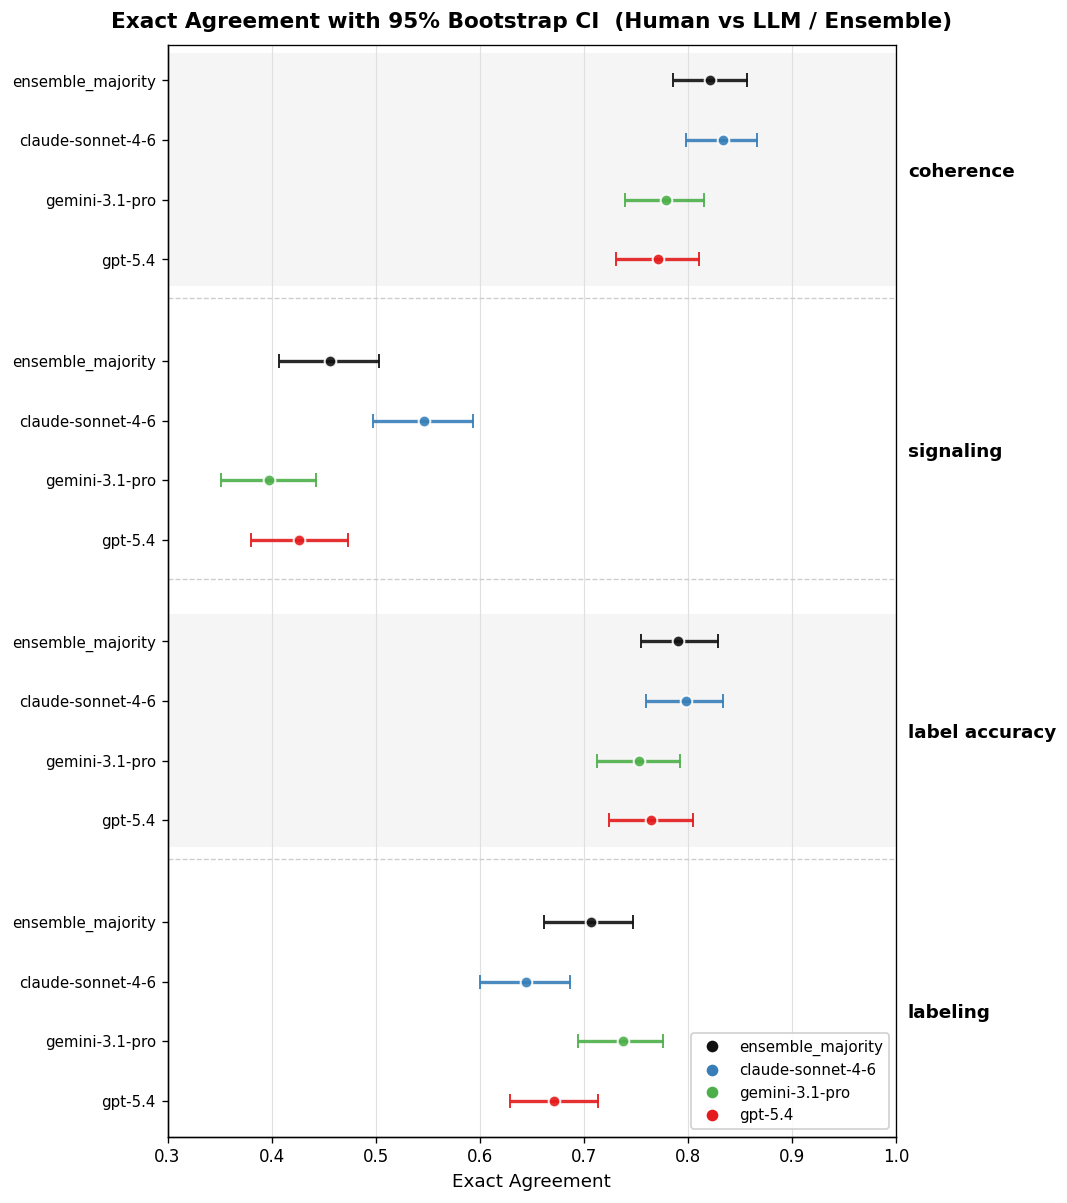

Saved: analysis_plots/ci_dotplot_exact_agreement.png


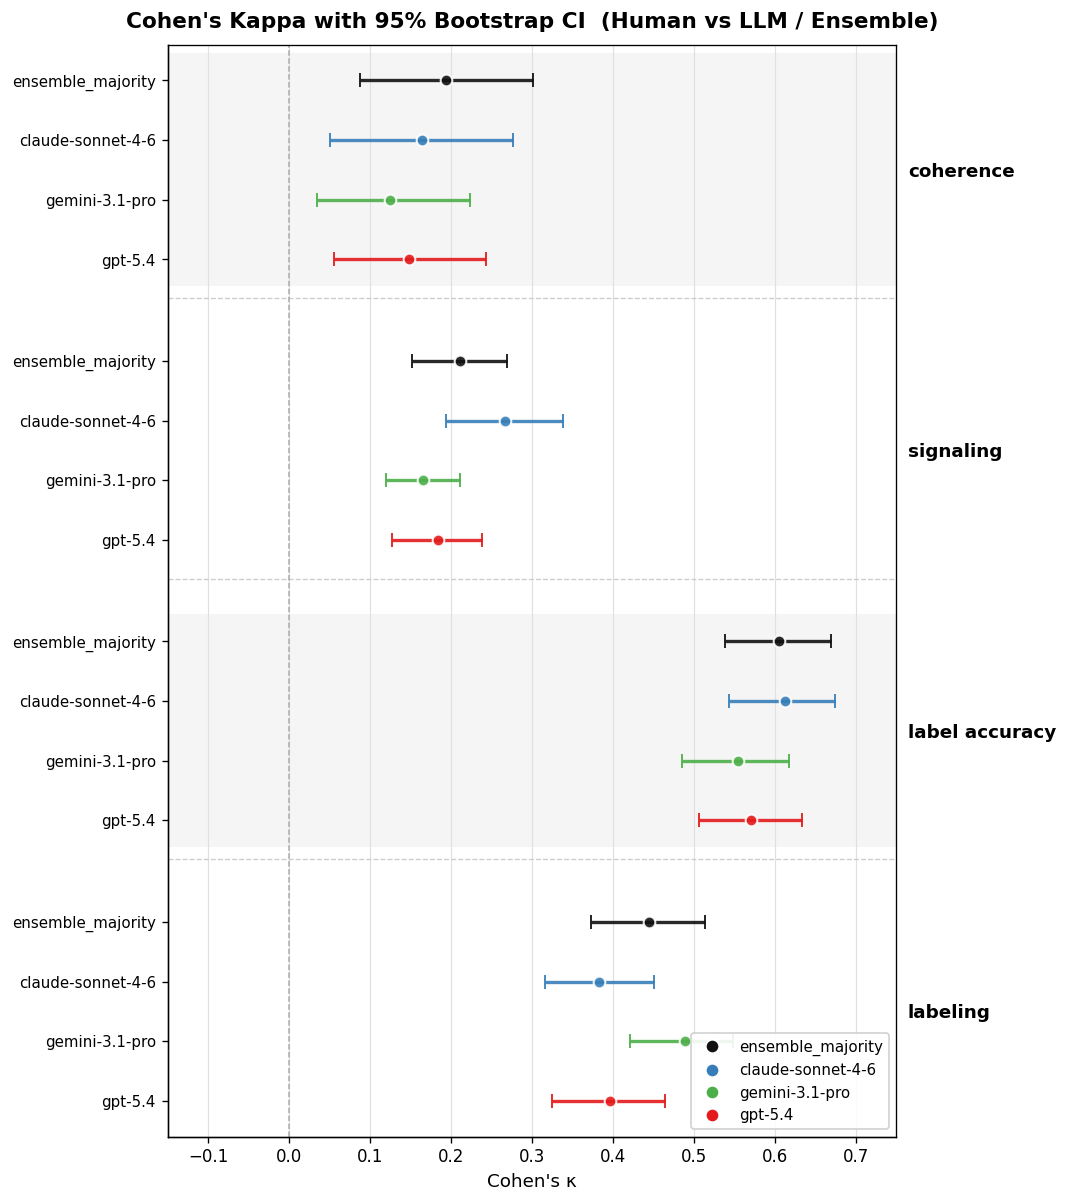

Saved: analysis_plots/ci_dotplot_kappa.png
Saved: analysis_plots/ci_dotplot_kappa_ensemble_vs_single.png


In [7]:
# ── CI dot-plot visualisation (matplotlib) ────────────────────────────────────
MODEL_COLORS = {
    ENSEMBLE_MODEL_NAME:           "#111111",
    "claude-sonnet-4-6":          "#377eb8",
    "gemini-3.1-pro-preview":     "#4daf4a",
    "gpt-5.4":                    "#e41a1c",
}
MODELS_ORDERED = [ENSEMBLE_MODEL_NAME, "claude-sonnet-4-6", "gemini-3.1-pro-preview", "gpt-5.4"]


def plot_ci_dotplot(ci_df, metric_col, lo_col, hi_col, title, xlabel, xlim=None):
    """Horizontal dot-plot with 95% bootstrap CI bars, grouped by dimension."""
    GAP = 0.7
    y_pos = {}
    y_tick_pos, y_tick_labels = [], []
    dim_midpoints, dim_band_extents, dim_sep_y = {}, {}, []

    y = 0.0
    for d_idx, dim in enumerate(DIMENSIONS):
        if d_idx > 0:
            dim_sep_y.append(y - GAP / 2)
            y += GAP
        dim_start = y
        for model in MODELS_ORDERED:
            y_pos[(dim, model)] = y
            y_tick_pos.append(y)
            y_tick_labels.append(MODEL_DISPLAY_NAMES.get(model, model))
            y += 1
        dim_midpoints[dim] = (dim_start + y - 1) / 2
        dim_band_extents[dim] = (dim_start - 0.45, y - 1 + 0.45)
    total_y = y - 1

    fig, ax = plt.subplots(figsize=(9, (total_y + 1) * 0.46 + 1.8))

    for d_idx, dim in enumerate(DIMENSIONS):
        lo_y, hi_y = dim_band_extents[dim]
        if d_idx % 2 == 0:
            ax.axhspan(lo_y, hi_y, color="#f5f5f5", zorder=0, linewidth=0)

    for sep in dim_sep_y:
        ax.axhline(sep, color="#cccccc", linewidth=0.8, linestyle="--", zorder=1)

    if xlim and xlim[0] < 0 < xlim[1]:
        ax.axvline(0, color="#aaa", linewidth=0.9, linestyle="--", zorder=1)

    for dim in DIMENSIONS:
        for model in MODELS_ORDERED:
            sub = ci_df[(ci_df["model"] == model) & (ci_df["dimension"] == dim)]
            if sub.empty:
                continue
            row = sub.iloc[0]
            color = MODEL_COLORS[model]
            xerr_lo = max(0.0, row[metric_col] - row[lo_col])
            xerr_hi = max(0.0, row[hi_col] - row[metric_col])
            ax.errorbar(
                row[metric_col], y_pos[(dim, model)],
                xerr=[[xerr_lo], [xerr_hi]],
                fmt="o", color=color, ecolor=color,
                elinewidth=2.0, capsize=4, capthick=1.5,
                markersize=7, markeredgecolor="white", markeredgewidth=1.2,
                alpha=0.9, zorder=3,
            )

    ax.set_yticks(y_tick_pos)
    ax.set_yticklabels(y_tick_labels, fontsize=9)
    ax.set_ylim(-0.6, total_y + 0.6)
    ax.invert_yaxis()

    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks([dim_midpoints[d] for d in DIMENSIONS])
    ax2.set_yticklabels(
        [d.replace("_", " ") for d in DIMENSIONS],
        fontsize=11, fontweight="bold",
    )
    ax2.tick_params(right=False)

    if xlim:
        ax.set_xlim(xlim)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.grid(axis="x", color="#e0e0e0", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=MODEL_COLORS[m], markersize=8,
                   label=MODEL_DISPLAY_NAMES.get(m, m))
        for m in MODELS_ORDERED
    ]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9, framealpha=0.9, borderaxespad=0.0)
    fig.tight_layout(rect=(0, 0, 0.84, 1))
    return fig


fig_ea = plot_ci_dotplot(
    ci_df, "exact_agreement", "ea_ci_lo", "ea_ci_hi",
    title="Exact Agreement with 95% Bootstrap CI  (Human vs LLM / Ensemble)",
    xlabel="Exact Agreement",
    xlim=(0.3, 1.0),
)
savefig(fig_ea, PLOT_DIR / "ci_dotplot_exact_agreement.png")

fig_kap = plot_ci_dotplot(
    ci_df, "cohens_kappa", "kappa_ci_lo", "kappa_ci_hi",
    title="Cohen's Kappa with 95% Bootstrap CI  (Human vs LLM / Ensemble)",
    xlabel="Cohen's κ",
    xlim=(-0.15, 0.75),
)
savefig(fig_kap, PLOT_DIR / "ci_dotplot_kappa.png")
savefig(fig_kap, PLOT_DIR / "ci_dotplot_kappa_ensemble_vs_single.png")


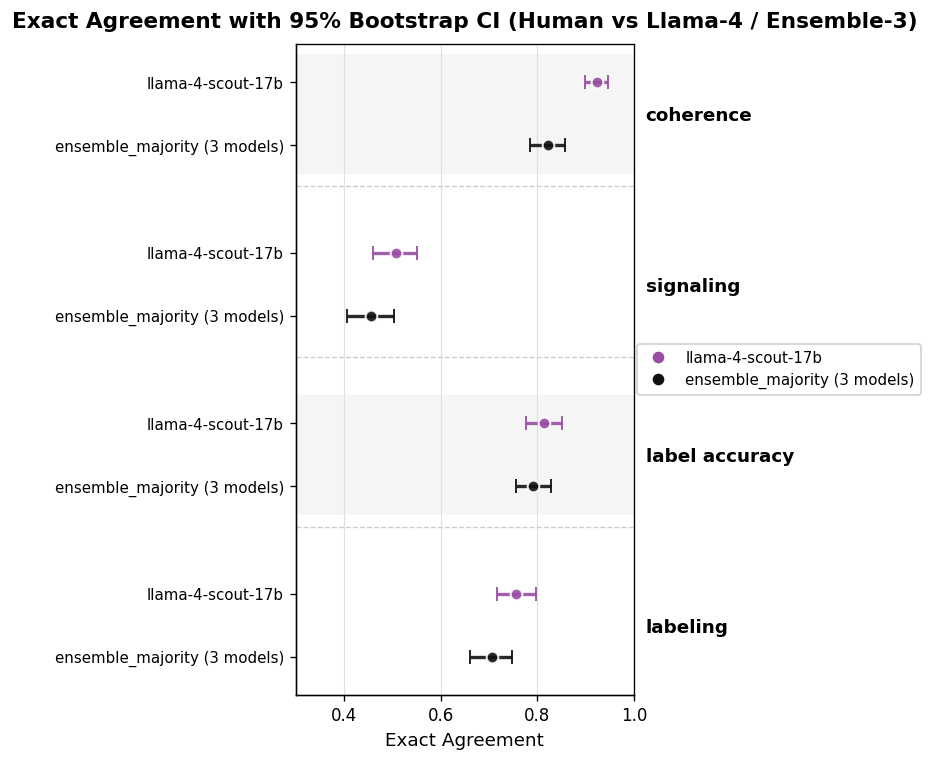

Saved: analysis_plots/ci_dotplot_exact_agreement_llama4_vs_ensemble3.png


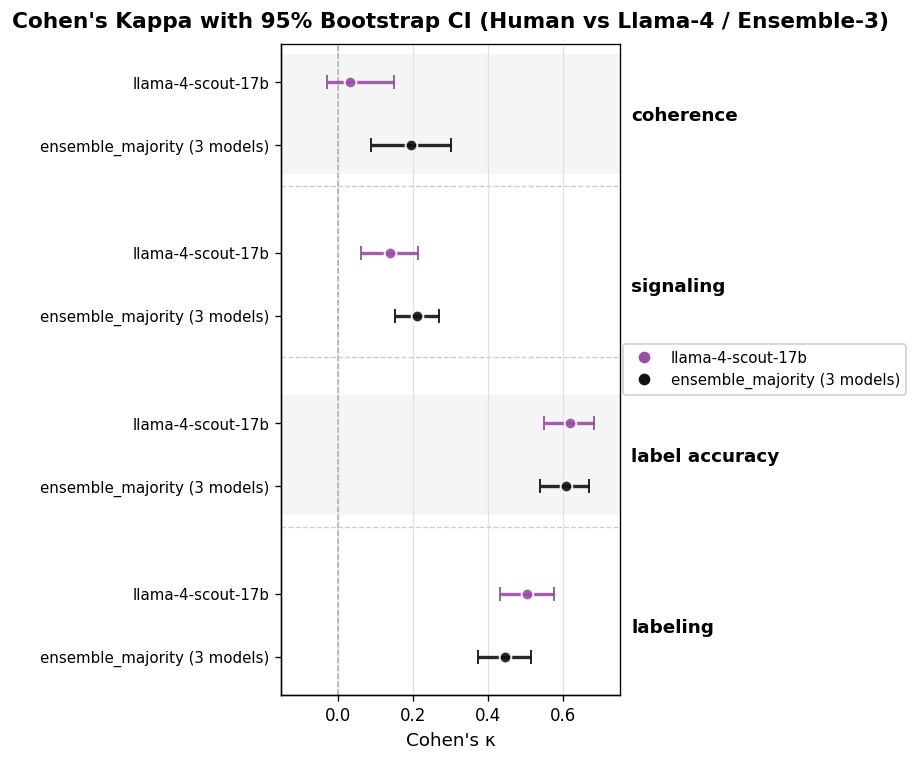

Saved: analysis_plots/ci_dotplot_kappa_llama4_vs_ensemble3.png


,model,dimension,n,exact_agreement,cohens_kappa
0,ensemble_majority,coherence,448,0.821429,0.194245
1,meta-llama/llama-4-scout-17b-16e-instruct,coherence,448,0.924107,0.033993
2,ensemble_majority,label_accuracy,449,0.790646,0.605923
3,meta-llama/llama-4-scout-17b-16e-instruct,label_accuracy,448,0.814732,0.616794
4,ensemble_majority,labeling,443,0.706546,0.444932
5,meta-llama/llama-4-scout-17b-16e-instruct,labeling,448,0.756696,0.503659
6,ensemble_majority,signaling,423,0.456265,0.211403
7,meta-llama/llama-4-scout-17b-16e-instruct,signaling,448,0.506696,0.138214


In [11]:
# ── CI dot-plot visualisation (Llama-4 vs 3-model ensemble) ────────────────
from pathlib import Path

LLAMA_MODEL_NAME = 'meta-llama/llama-4-scout-17b-16e-instruct'
LLAMA_RESULTS_GLOB = 'pedagogical_eval_*.json'
ENSEMBLE_3_DISPLAY_NAME = 'ensemble_majority (3 models)'

def find_latest_llama_result(results_dir: Path, model_name: str):
    """Return the newest pedagogical_eval JSON that contains Llama-4 rows."""
    candidates = sorted(results_dir.glob(LLAMA_RESULTS_GLOB), reverse=True)
    for path in candidates:
        records = load_json(path)
        if not isinstance(records, list) or not records:
            continue
        sample_model = str(records[0].get("model", "")) if isinstance(records[0], dict) else ""
        if model_name in sample_model:
            return path
        if any(isinstance(r, dict) and str(r.get("model", "")) == model_name for r in records[:20]):
            return path
    return None

def plot_ci_dotplot_subset(
    ci_df,
    metric_col,
    lo_col,
    hi_col,
    title,
    xlabel,
    models_ordered,
    model_colors,
    model_display_names,
    xlim=None,
):
    """Horizontal dot-plot with 95% CI bars for a chosen model subset."""
    GAP = 0.7
    y_pos = {}
    y_tick_pos, y_tick_labels = [], []
    dim_midpoints, dim_band_extents, dim_sep_y = {}, {}, []

    y = 0.0
    for d_idx, dim in enumerate(DIMENSIONS):
        if d_idx > 0:
            dim_sep_y.append(y - GAP / 2)
            y += GAP
        dim_start = y
        for model in models_ordered:
            y_pos[(dim, model)] = y
            y_tick_pos.append(y)
            y_tick_labels.append(model_display_names.get(model, model))
            y += 1
        dim_midpoints[dim] = (dim_start + y - 1) / 2
        dim_band_extents[dim] = (dim_start - 0.45, y - 1 + 0.45)
    total_y = y - 1

    fig, ax = plt.subplots(figsize=(9, (total_y + 1) * 0.46 + 1.8))

    for d_idx, dim in enumerate(DIMENSIONS):
        lo_y, hi_y = dim_band_extents[dim]
        if d_idx % 2 == 0:
            ax.axhspan(lo_y, hi_y, color="#f5f5f5", zorder=0, linewidth=0)

    for sep in dim_sep_y:
        ax.axhline(sep, color="#cccccc", linewidth=0.8, linestyle="--", zorder=1)

    if xlim and xlim[0] < 0 < xlim[1]:
        ax.axvline(0, color="#aaa", linewidth=0.9, linestyle="--", zorder=1)

    for dim in DIMENSIONS:
        for model in models_ordered:
            sub = ci_df[(ci_df["model"] == model) & (ci_df["dimension"] == dim)]
            if sub.empty:
                continue
            row = sub.iloc[0]
            color = model_colors[model]
            xerr_lo = max(0.0, row[metric_col] - row[lo_col])
            xerr_hi = max(0.0, row[hi_col] - row[metric_col])
            ax.errorbar(
                row[metric_col], y_pos[(dim, model)],
                xerr=[[xerr_lo], [xerr_hi]],
                fmt="o", color=color, ecolor=color,
                elinewidth=2.0, capsize=4, capthick=1.5,
                markersize=7, markeredgecolor="white", markeredgewidth=1.2,
                alpha=0.9, zorder=3,
            )

    ax.set_yticks(y_tick_pos)
    ax.set_yticklabels(y_tick_labels, fontsize=9)
    ax.set_ylim(-0.6, total_y + 0.6)
    ax.invert_yaxis()

    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks([dim_midpoints[d] for d in DIMENSIONS])
    ax2.set_yticklabels([d.replace("_", " ") for d in DIMENSIONS], fontsize=11, fontweight="bold")
    ax2.tick_params(right=False)

    if xlim:
        ax.set_xlim(xlim)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.grid(axis="x", color="#e0e0e0", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=model_colors[m], markersize=8,
                   label=model_display_names.get(m, m))
        for m in models_ordered
    ]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9, framealpha=0.9, borderaxespad=0.0)
    fig.tight_layout(rect=(0, 0, 0.84, 1))
    return fig

llama_path = find_latest_llama_result(ROOT / "results", LLAMA_MODEL_NAME)
if llama_path is None:
    raise FileNotFoundError("Could not find a results/pedagogical_eval_*.json containing Llama-4.")

base_frames = []
for model_name, path in MODEL_FILES.items():
    base_frames.append(extract_llm_rows(load_json(path), model_name))
llm_base3_long = pd.concat(base_frames, ignore_index=True)

ensemble_rows = []
for (diagram_id, dimension), group in llm_base3_long.groupby(["diagram_id", "dimension"]):
    voted_label, _ = majority_vote_label(group["value"].tolist())
    if voted_label in LABEL_ORDER:
        ensemble_rows.append(
            {
                "diagram_id": diagram_id,
                "model": ENSEMBLE_MODEL_NAME,
                "dimension": dimension,
                "value": voted_label,
            }
        )
ensemble_3_long = pd.DataFrame(ensemble_rows)
if ensemble_3_long.empty:
    ensemble_3_long = pd.DataFrame(columns=["diagram_id", "model", "dimension", "value"])

llama_long = extract_llm_rows(load_json(llama_path), LLAMA_MODEL_NAME)
subset_eval_long = pd.concat([llama_long, ensemble_3_long], ignore_index=True)

subset_comparison = (
    human_consensus.rename(columns={"value": "human_value"})
    .merge(
        subset_eval_long.rename(columns={"value": "llm_value"}),
        on=["diagram_id", "dimension"],
        how="inner",
    )
)
subset_comparison = subset_comparison[
    subset_comparison["human_value"].isin(LABEL_ORDER)
    & subset_comparison["llm_value"].isin(LABEL_ORDER)
].copy()

def _exact_agreement_subset(h, p):
    return np.mean(h == p)

def _kappa_subset(h, p):
    return cohens_kappa(h.tolist(), p.tolist(), LABEL_ORDER)

subset_ci_rows = []
for (model_name, dim), g in subset_comparison.groupby(["model", "dimension"]):
    h = g["human_value"].to_numpy()
    p = g["llm_value"].to_numpy()
    ea = float(np.mean(h == p))
    kap = cohens_kappa(h.tolist(), p.tolist(), LABEL_ORDER)
    ea_lo, ea_hi = bootstrap_ci(h, p, _exact_agreement_subset)
    kap_lo, kap_hi = bootstrap_ci(h, p, _kappa_subset)
    subset_ci_rows.append(
        dict(
            model=model_name,
            dimension=dim,
            n=len(g),
            exact_agreement=ea,
            ea_ci_lo=ea_lo,
            ea_ci_hi=ea_hi,
            cohens_kappa=kap,
            kappa_ci_lo=kap_lo,
            kappa_ci_hi=kap_hi,
        )
    )

subset_ci_df = (
    pd.DataFrame(subset_ci_rows)
    .sort_values(["dimension", "model"])
    .reset_index(drop=True)
)

subset_models_ordered = [LLAMA_MODEL_NAME, ENSEMBLE_MODEL_NAME]
subset_display_names = {
    LLAMA_MODEL_NAME: "llama-4-scout-17b",
    ENSEMBLE_MODEL_NAME: ENSEMBLE_3_DISPLAY_NAME,
}
subset_colors = {
    LLAMA_MODEL_NAME: "#984ea3",
    ENSEMBLE_MODEL_NAME: "#111111",
}

fig_ea_subset = plot_ci_dotplot_subset(
    subset_ci_df,
    "exact_agreement",
    "ea_ci_lo",
    "ea_ci_hi",
    title="Exact Agreement with 95% Bootstrap CI (Human vs Llama-4 / Ensemble-3)",
    xlabel="Exact Agreement",
    models_ordered=subset_models_ordered,
    model_colors=subset_colors,
    model_display_names=subset_display_names,
    xlim=(0.3, 1.0),
)
savefig(fig_ea_subset, PLOT_DIR / "ci_dotplot_exact_agreement_llama4_vs_ensemble3.png")

fig_kap_subset = plot_ci_dotplot_subset(
    subset_ci_df,
    "cohens_kappa",
    "kappa_ci_lo",
    "kappa_ci_hi",
    title="Cohen's Kappa with 95% Bootstrap CI (Human vs Llama-4 / Ensemble-3)",
    xlabel="Cohen's κ",
    models_ordered=subset_models_ordered,
    model_colors=subset_colors,
    model_display_names=subset_display_names,
    xlim=(-0.15, 0.75),
)
savefig(fig_kap_subset, PLOT_DIR / "ci_dotplot_kappa_llama4_vs_ensemble3.png")

display(subset_ci_df[["model", "dimension", "n", "exact_agreement", "cohens_kappa"]])


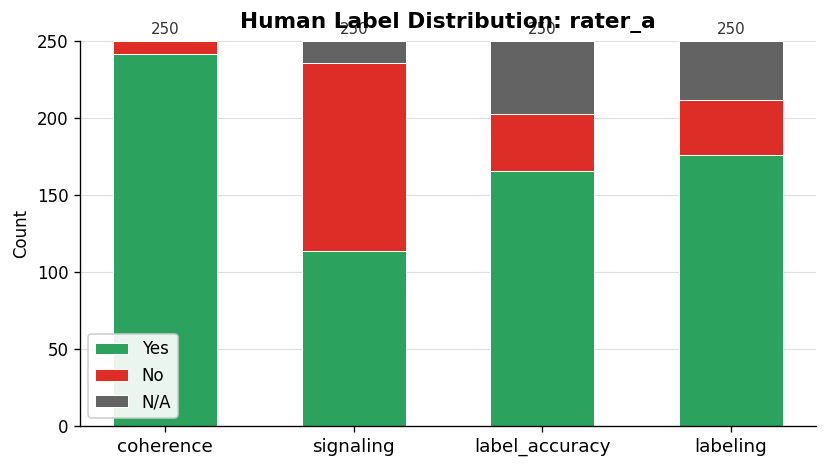

Saved: analysis_plots/human_distribution_rater_a.png


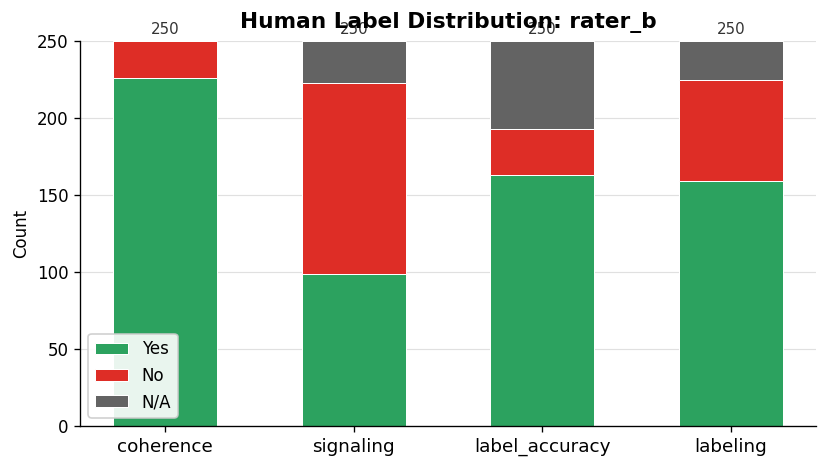

Saved: analysis_plots/human_distribution_rater_b.png


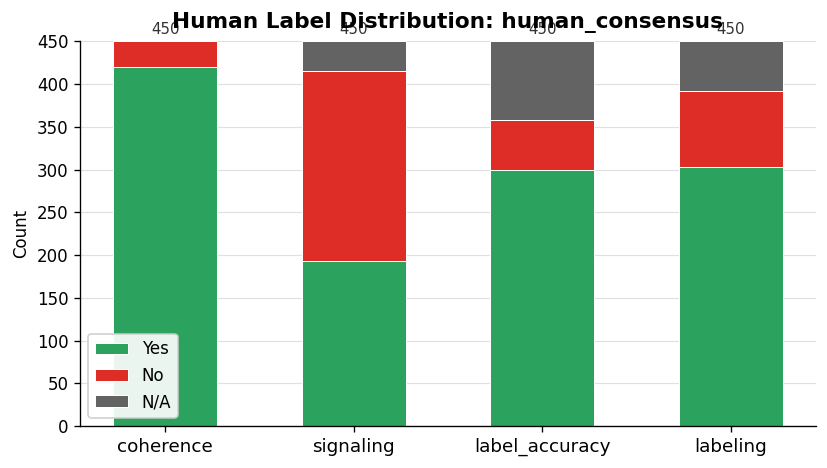

Saved: analysis_plots/human_distribution_human_consensus.png


In [8]:
# Plot 1: Human label distributions by rater and final consensus.
human_sources = {
    "rater_a": human_long[human_long["rater"] == "A"][["dimension", "value"]],
    "rater_b": human_long[human_long["rater"] == "B"][["dimension", "value"]],
    "human_consensus": human_consensus[["dimension", "value"]],
}

for source_name, source_df in human_sources.items():
    counts = (
        source_df.groupby(["dimension", "value"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=DIMENSIONS, columns=LABEL_ORDER, fill_value=0)
    )
    fig = plot_stacked_bar(
        counts,
        title=f"Human Label Distribution: {source_name}",
        colors=LABEL_COLORS,
    )
    out_path = PLOT_DIR / f"human_distribution_{source_name}.png"
    savefig(fig, out_path)


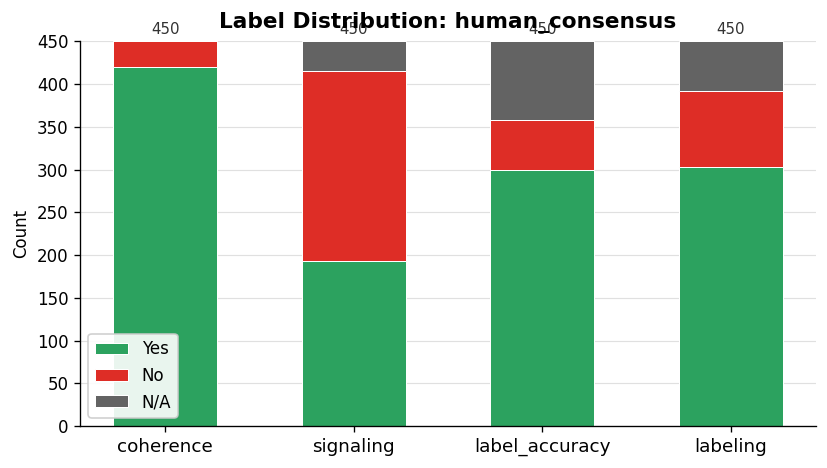

Saved: analysis_plots/distribution_human_consensus.png


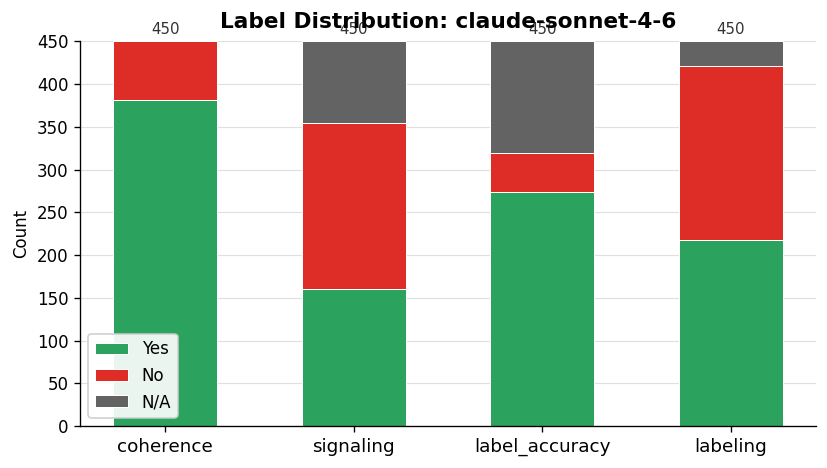

Saved: analysis_plots/distribution_claude-sonnet-4-6.png


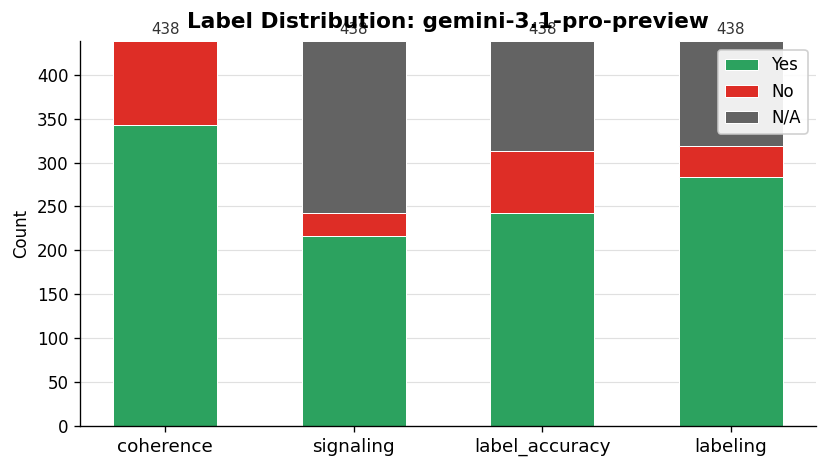

Saved: analysis_plots/distribution_gemini-3.1-pro-preview.png


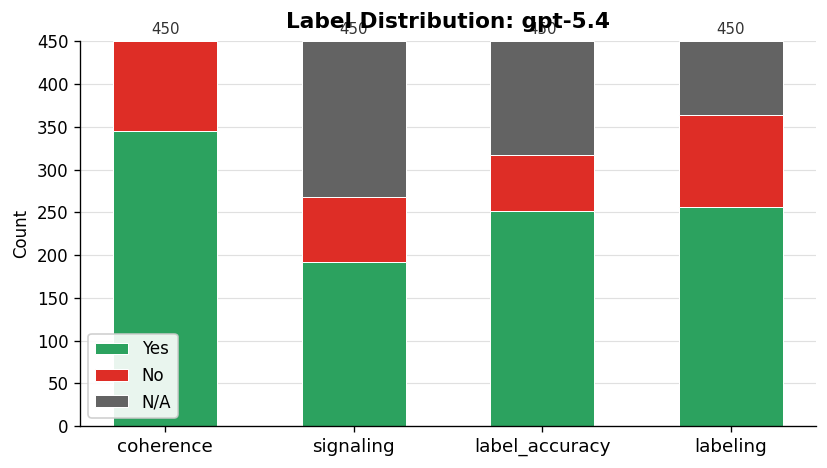

Saved: analysis_plots/distribution_gpt-5.4.png


In [9]:
# Plot 2: Label distributions for human consensus and each LLM.
distribution_sources = [
    ("human_consensus", human_consensus[["dimension", "value"]]),
]
for model_name in sorted(llm_long["model"].unique()):
    distribution_sources.append(
        (model_name, llm_long[llm_long["model"] == model_name][["dimension", "value"]])
    )

for source_name, source_df in distribution_sources:
    counts = (
        source_df.groupby(["dimension", "value"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=DIMENSIONS, columns=LABEL_ORDER, fill_value=0)
    )
    fig = plot_stacked_bar(
        counts,
        title=f"Label Distribution: {source_name}",
        colors=LABEL_COLORS,
    )
    safe_name = source_name.replace("/", "_").replace(" ", "_")
    out_path = PLOT_DIR / f"distribution_{safe_name}.png"
    savefig(fig, out_path)


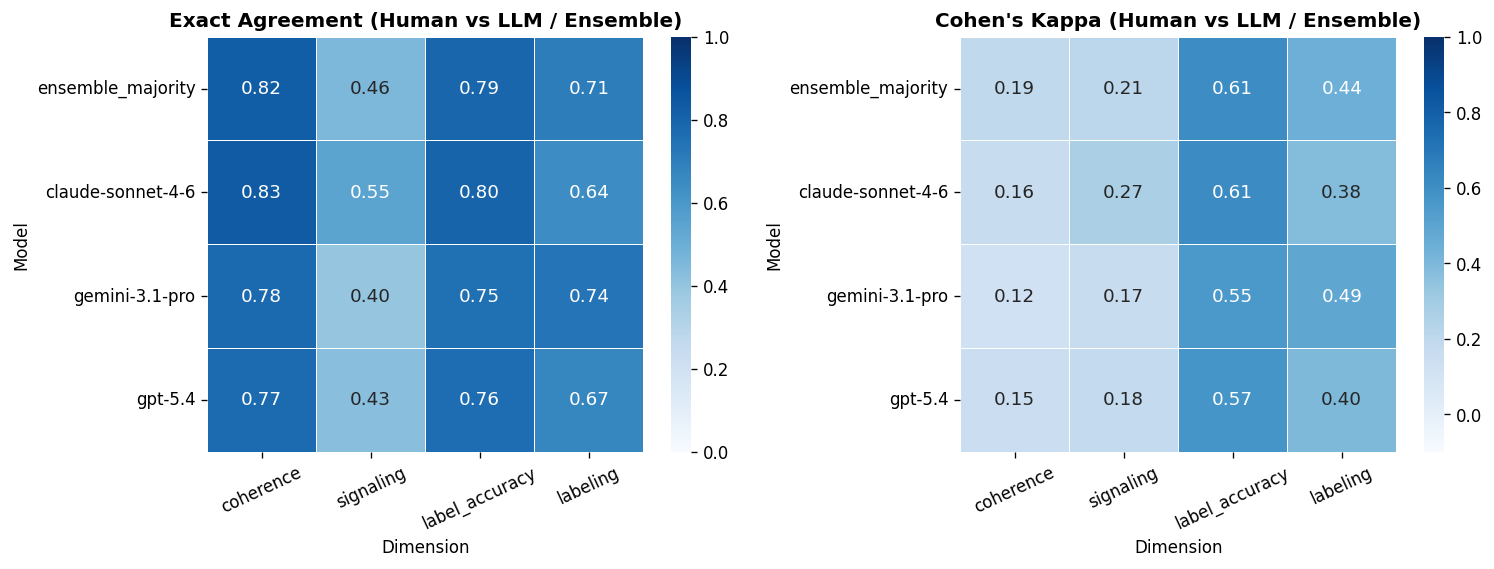

Saved: analysis_plots/agreement_kappa_heatmaps.png
Saved: analysis_plots/agreement_kappa_heatmaps.svg


In [10]:
# Plot 3: Agreement and kappa heatmaps (seaborn).
# Ensemble first, then individual models alphabetically
MODEL_ROW_ORDER = [ENSEMBLE_MODEL_NAME, "claude-sonnet-4-6", "gemini-3.1-pro-preview", "gpt-5.4"]
_available_models = metrics_df["model"].unique().tolist()
_row_order = [m for m in MODEL_ROW_ORDER if m in _available_models]

agreement_matrix = (
    metrics_df.pivot(index="model", columns="dimension", values="exact_agreement")
    .reindex(index=_row_order, columns=DIMENSIONS)
)
kappa_matrix = (
    metrics_df.pivot(index="model", columns="dimension", values="cohens_kappa")
    .reindex(index=_row_order, columns=DIMENSIONS)
)

_row_labels = [MODEL_DISPLAY_NAMES.get(m, m) for m in _row_order]

fig, axes = plt.subplots(1, 2, figsize=(13, max(3.8, len(_row_order) * 0.9 + 1.5)))

sns.heatmap(
    agreement_matrix.astype(float),
    ax=axes[0], annot=True, fmt=".2f", cmap="Blues",
    vmin=0.0, vmax=1.0,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 11},
    yticklabels=_row_labels,
)
axes[0].set_title("Exact Agreement (Human vs LLM / Ensemble)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Dimension", fontsize=10)
axes[0].set_ylabel("Model", fontsize=10)
axes[0].tick_params(axis="x", rotation=25)
axes[0].tick_params(axis="y", rotation=0)

sns.heatmap(
    kappa_matrix.astype(float),
    ax=axes[1], annot=True, fmt=".2f", cmap="Blues",
    vmin=-0.1, vmax=1.0,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 11},
    yticklabels=_row_labels,
)
axes[1].set_title("Cohen\'s Kappa (Human vs LLM / Ensemble)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Dimension", fontsize=10)
axes[1].set_ylabel("Model", fontsize=10)
axes[1].tick_params(axis="x", rotation=25)
axes[1].tick_params(axis="y", rotation=0)

fig.tight_layout(pad=2.0)
savefig(fig, PLOT_DIR / "agreement_kappa_heatmaps.png")
savefig(fig, PLOT_DIR / "agreement_kappa_heatmaps.svg")


In [11]:
print("Generated plot files:")
for path in sorted(PLOT_DIR.glob("*.svg")):
    print("-", path)

Generated plot files:
- analysis_plots/agreement_kappa_heatmaps.svg
- analysis_plots/distribution_claude-sonnet-4-6.svg
- analysis_plots/distribution_gemini-3.1-pro-preview.svg
- analysis_plots/distribution_gpt-5.4.svg
- analysis_plots/distribution_human_consensus.svg
- analysis_plots/ensemble_confusion_matrices.svg
- analysis_plots/ensemble_label_dist_comparison.svg
- analysis_plots/ensemble_vs_single_kappa_bar.svg
- analysis_plots/exact_agreement_heatmap.svg
- analysis_plots/human_distribution_human_consensus.svg
- analysis_plots/human_distribution_rater_a.svg
- analysis_plots/human_distribution_rater_b.svg
- analysis_plots/kappa_heatmap.svg
- analysis_plots/signaling_per_model_confusion_matrices.svg
- analysis_plots/spider_kappa.svg


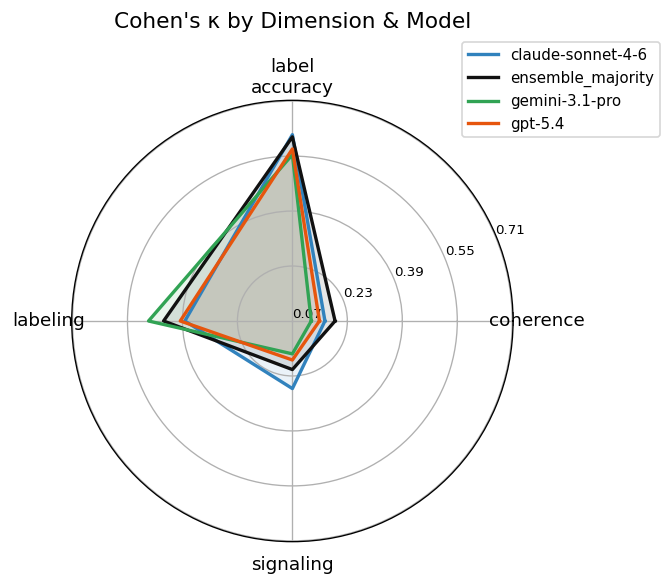

Saved: analysis_plots/spider_kappa.png
Saved: analysis_plots/spider_kappa.svg


In [12]:
# ── Spider / Radar plot: Cohen's kappa per dimension, all models overlaid ──────
import matplotlib.pyplot as plt
import numpy as np

MODEL_COLORS = {
    ENSEMBLE_MODEL_NAME:           "#111111",
    "gpt-5.4":                    "#e6550d",
    "claude-sonnet-4-6":          "#3182bd",
    "gemini-3.1-pro-preview":     "#31a354",
}

# Pivot: rows = models, columns = dimensions
kappa_pivot = metrics_df.pivot(index="model", columns="dimension", values="cohens_kappa")
dims = list(kappa_pivot.columns)
N = len(dims)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]          # close the loop

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for model, row in kappa_pivot.iterrows():
    values = row[dims].tolist()
    values += values[:1]       # close the loop
    color = MODEL_COLORS.get(model, "#888888")
    ax.plot(angles, values, color=color, linewidth=2, label=MODEL_DISPLAY_NAMES.get(model, model))
    ax.fill(angles, values, color=color, alpha=0.10)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [d.replace("_", "\n") for d in dims],
    fontsize=11,
)

# Radial scale: kappa can be negative, but clamp to a sensible range
kap_min = max(-0.1, kappa_pivot.values.min() - 0.05)
kap_max = min(1.0,  kappa_pivot.values.max() + 0.10)
ax.set_ylim(kap_min, kap_max)
ax.set_yticks(np.round(np.linspace(kap_min, kap_max, 5), 2))
ax.yaxis.set_tick_params(labelsize=8)

ax.set_title("Cohen's κ by Dimension & Model", fontsize=13, pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)

fig.tight_layout()
savefig(fig, PLOT_DIR / "spider_kappa.png")
savefig(fig, PLOT_DIR / "spider_kappa.svg")
plt.show()


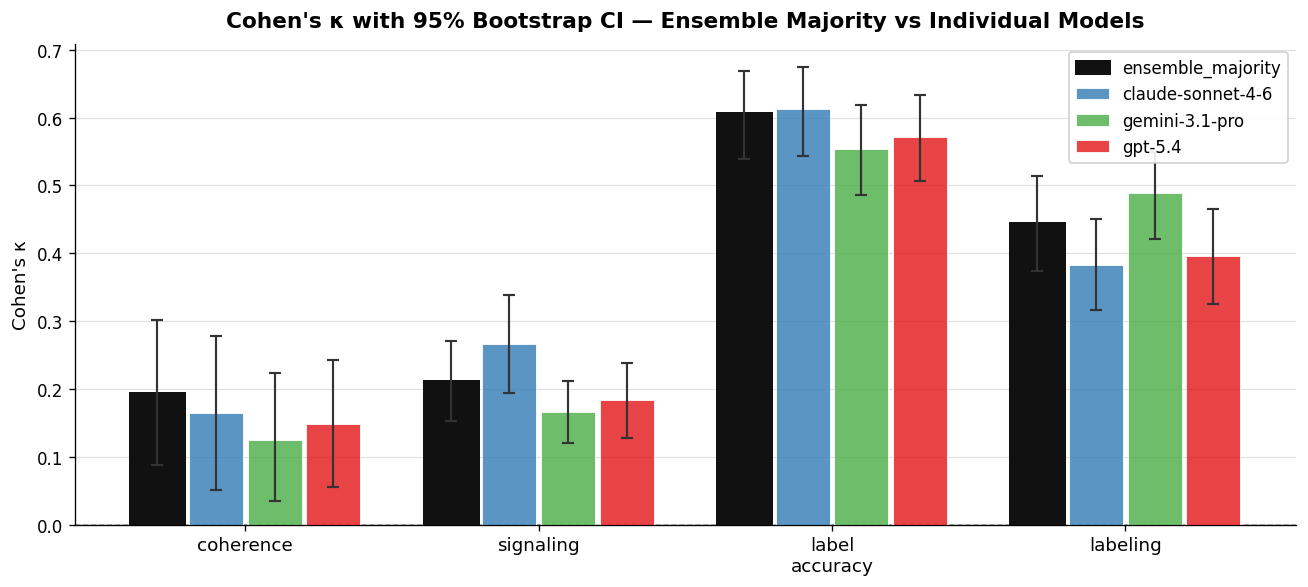

Saved: analysis_plots/ensemble_vs_single_kappa_bar.png
Saved: analysis_plots/ensemble_vs_single_kappa_bar.svg


In [13]:
# ── Ensemble vs Individual Models: Grouped bar chart, Cohen's κ with 95% CI ────
# Requires ci_df (bootstrap CI cell) and metrics_df to be computed first.

_BAR_COLORS = {
    ENSEMBLE_MODEL_NAME:        "#111111",
    "claude-sonnet-4-6":       "#377eb8",
    "gemini-3.1-pro-preview":  "#4daf4a",
    "gpt-5.4":                 "#e41a1c",
}
_MODELS_PLOT_ORDER = [ENSEMBLE_MODEL_NAME, "claude-sonnet-4-6", "gemini-3.1-pro-preview", "gpt-5.4"]
_MODELS_AVAILABLE  = [m for m in _MODELS_PLOT_ORDER if m in ci_df["model"].unique()]

n_dims   = len(DIMENSIONS)
n_models = len(_MODELS_AVAILABLE)
group_width = 0.80
bar_width   = group_width / n_models
x_base = np.arange(n_dims)

fig, ax = plt.subplots(figsize=(11, 5))

for m_idx, model in enumerate(_MODELS_AVAILABLE):
    sub = ci_df[ci_df["model"] == model].set_index("dimension")
    offsets = x_base + (m_idx - (n_models - 1) / 2) * bar_width

    kappas  = [sub.loc[d, "cohens_kappa"]   if d in sub.index else np.nan for d in DIMENSIONS]
    lo_errs = [max(0, sub.loc[d, "cohens_kappa"] - sub.loc[d, "kappa_ci_lo"]) if d in sub.index else 0 for d in DIMENSIONS]
    hi_errs = [max(0, sub.loc[d, "kappa_ci_hi"] - sub.loc[d, "cohens_kappa"]) if d in sub.index else 0 for d in DIMENSIONS]

    is_ensemble = (model == ENSEMBLE_MODEL_NAME)
    color  = _BAR_COLORS[model]
    alpha  = 1.0 if is_ensemble else 0.82
    edge   = color if is_ensemble else "white"
    lw     = 1.8  if is_ensemble else 0.6

    ax.bar(
        offsets, kappas, bar_width * 0.92,
        color=color, alpha=alpha,
        label=MODEL_DISPLAY_NAMES.get(model, model),
        linewidth=lw, edgecolor=edge,
        zorder=3,
    )
    ax.errorbar(
        offsets, kappas,
        yerr=[lo_errs, hi_errs],
        fmt="none", ecolor="#333333", elinewidth=1.3,
        capsize=3.5, capthick=1.3,
        zorder=4,
    )

ax.set_xticks(x_base)
ax.set_xticklabels([d.replace("_", "\n") for d in DIMENSIONS], fontsize=11)
ax.set_ylabel("Cohen's κ", fontsize=11)
ax.set_title(
    "Cohen's κ with 95% Bootstrap CI — Ensemble Majority vs Individual Models",
    fontsize=13, fontweight="bold", pad=10,
)
ax.axhline(0, color="#aaaaaa", linewidth=0.9, linestyle="--", zorder=1)
ax.legend(fontsize=10, framealpha=0.9, loc="upper right")
ax.grid(axis="y", color="#e0e0e0", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

savefig(fig, PLOT_DIR / "ensemble_vs_single_kappa_bar.png")
savefig(fig, PLOT_DIR / "ensemble_vs_single_kappa_bar.svg")


## Ensemble Judge Analysis

Majority vote across GPT, Claude, and Gemini to produce a single **ensemble label** per diagram × dimension.

- A label wins if **≥ 2 of 3 models agree** (strict majority).
- Ties (all three models disagree, or only 2 models voted) result in `no_majority` and are excluded from downstream agreement stats.

The cells below show:
1. **Vote-pattern summary** — how often the three models agree unanimously vs. split 2-1 vs. produce no majority.
2. **Ensemble label distribution** vs. human consensus, per dimension.
3. **Inter-model agreement with the ensemble** — exact agreement and Cohen's κ for each individual model against the ensemble labels.
4. **Confusion matrices** — ensemble prediction vs. human consensus for each rubric dimension.

ENSEMBLE VOTE-PATTERN SUMMARY


,pattern,count,pct
0,3-model vote / majority,1726,95.9
1,2-model vote / majority,37,2.1
2,3-model vote / no_majority,26,1.4
3,2-model vote / no_majority,11,0.6



Total (diagram × dimension) slots : 1800
  Resolved by majority vote        : 1763  (97.9 %)
  No majority (excluded)           : 37  (2.1 %)

VOTE SPLIT AMONG MAJORITY-RESOLVED CASES


,description,count,pct
0,2/2 agree (unanimous),37,2.1
1,2/3 agree (split),590,33.5
2,3/3 agree (unanimous),1136,64.4



ENSEMBLE LABEL DISTRIBUTION vs HUMAN CONSENSUS — per dimension
  (proportions with 95 % Wilson score confidence intervals)

Ensemble majority:


,Yes,No,N/A
dimension,,,
coherence,"82.1 % [78.3, 85.4]","17.9 % [14.6, 21.7]","0.0 % [0.0, 0.9]"
label_accuracy,"59.2 % [54.6, 63.7]","12.2 % [9.5, 15.6]","28.5 % [24.5, 32.9]"
labeling,"59.6 % [55.0, 64.1]","21.4 % [17.9, 25.5]","19.0 % [15.6, 22.9]"
signaling,"44.0 % [39.3, 48.7]","18.2 % [14.8, 22.2]","37.8 % [33.3, 42.5]"



Human consensus:


,Yes,No,N/A
dimension,,,
coherence,"93.3 % [90.6, 95.3]","6.7 % [4.7, 9.4]","0.0 % [0.0, 0.8]"
label_accuracy,"66.7 % [62.2, 70.9]","12.9 % [10.1, 16.3]","20.4 % [17.0, 24.4]"
labeling,"67.3 % [62.9, 71.5]","19.8 % [16.4, 23.7]","12.9 % [10.1, 16.3]"
signaling,"42.9 % [38.4, 47.5]","49.3 % [44.7, 53.9]","7.8 % [5.6, 10.6]"


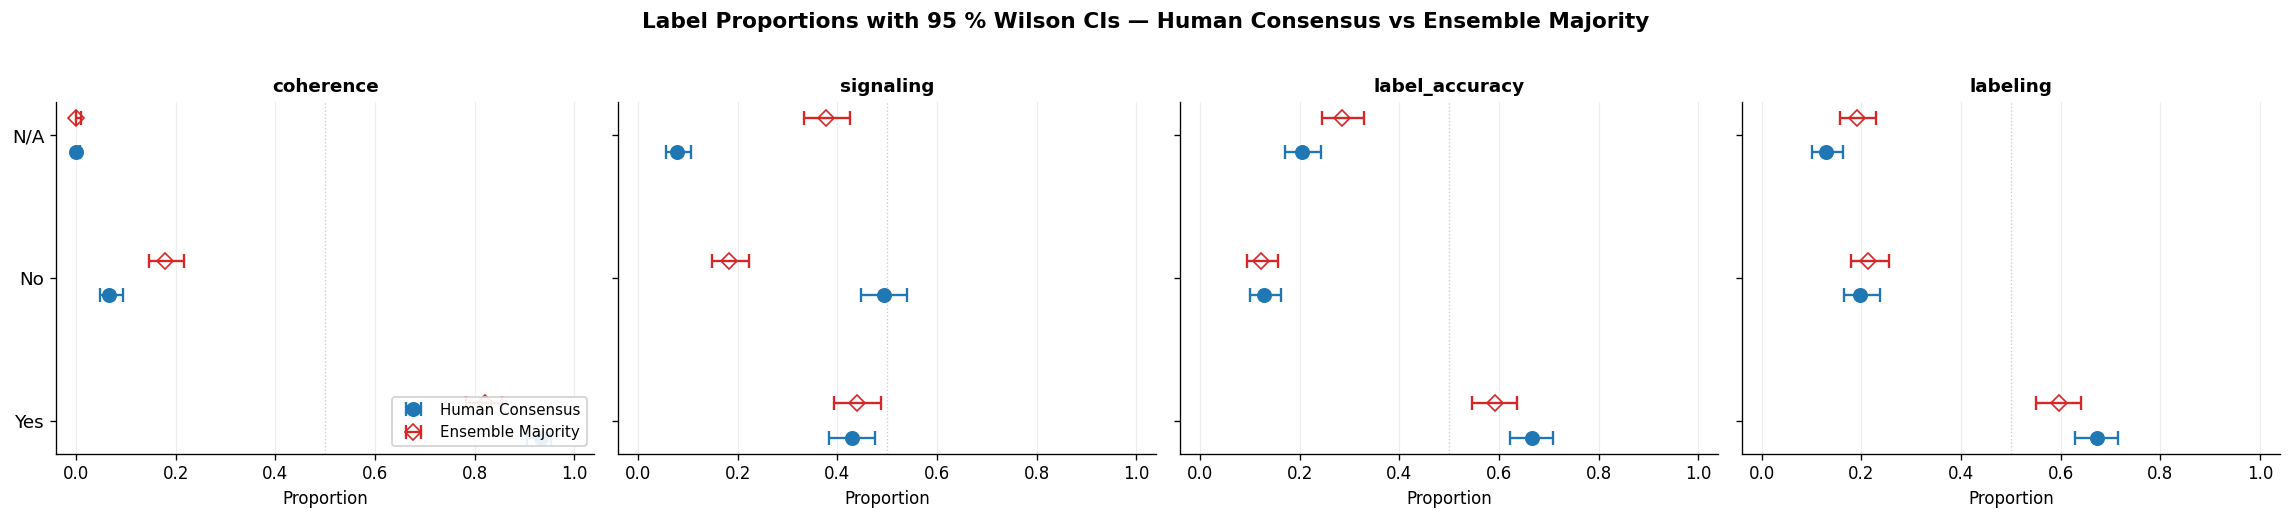

Saved: analysis_plots/ensemble_label_dist_comparison.png
Saved: analysis_plots/ensemble_label_dist_comparison.svg

INDIVIDUAL MODEL AGREEMENT WITH ENSEMBLE LABELS


,model,dimension,n,exact_agreement_vs_ensemble,kappa_vs_ensemble
4,claude-sonnet-4-6,coherence,448,0.9219,0.7156
8,gemini-3.1-pro-preview,coherence,438,0.8973,0.6766
0,gpt-5.4,coherence,448,0.8951,0.6814
6,claude-sonnet-4-6,label_accuracy,449,0.9287,0.8688
10,gemini-3.1-pro-preview,label_accuracy,438,0.9315,0.8800
2,gpt-5.4,label_accuracy,449,0.9577,0.9255
7,claude-sonnet-4-6,labeling,443,0.7585,0.5971
11,gemini-3.1-pro-preview,labeling,434,0.8525,0.7282
3,gpt-5.4,labeling,443,0.9526,0.9174
5,claude-sonnet-4-6,signaling,423,0.7683,0.6575



Mean across dimensions (vs ensemble):


,model,mean_exact,mean_kappa
2,gpt-5.4,0.9395,0.8623
1,gemini-3.1-pro-preview,0.8770,0.7495
0,claude-sonnet-4-6,0.8444,0.7098



CONFUSION MATRICES — Ensemble Majority vs Human Consensus


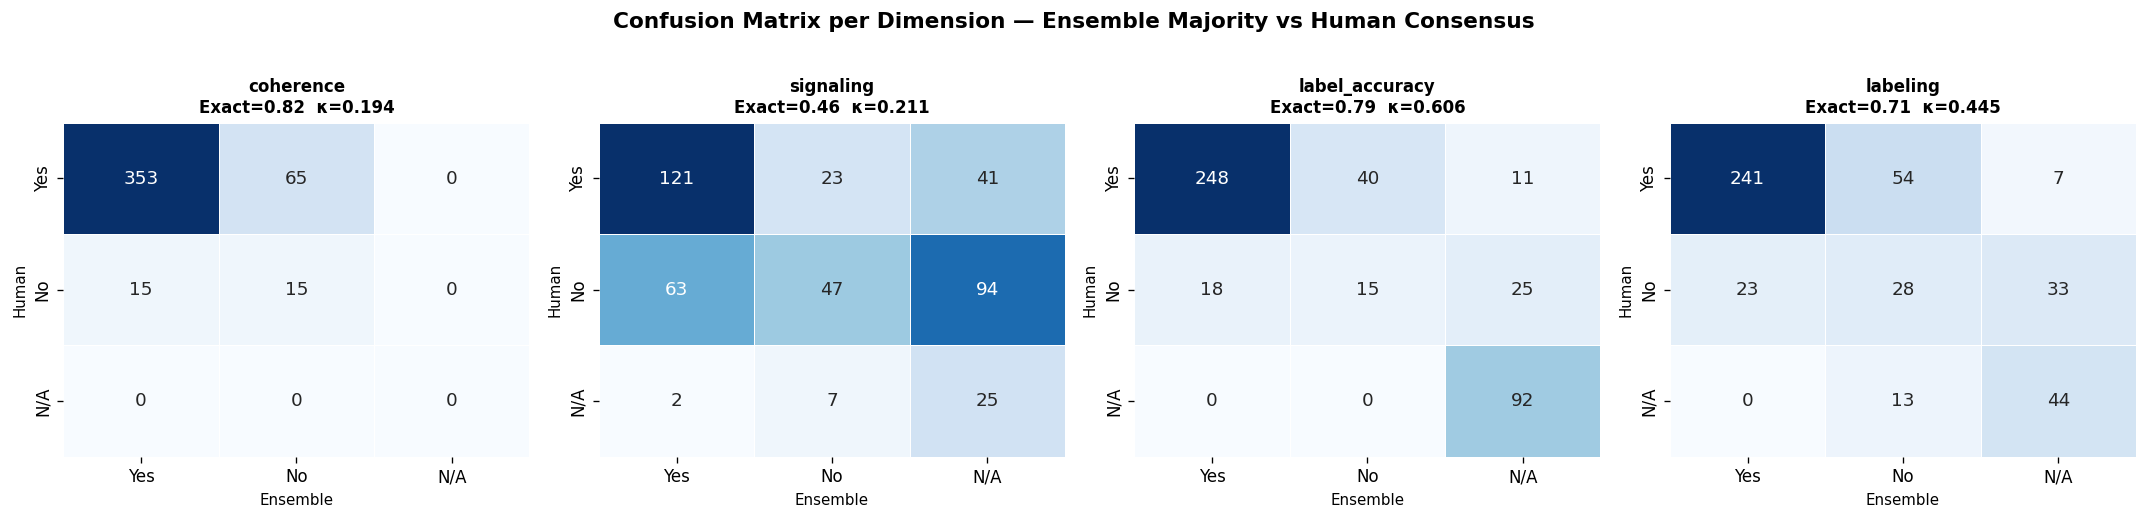

Saved: analysis_plots/ensemble_confusion_matrices.png
Saved: analysis_plots/ensemble_confusion_matrices.svg


In [14]:
# ── 1. Vote-pattern summary ──────────────────────────────────────────────────
print("=" * 60)
print("ENSEMBLE VOTE-PATTERN SUMMARY")
print("=" * 60)

vote_summary = ensemble_resolution_df.copy()
vote_summary["pattern"] = vote_summary.apply(
    lambda r: f"{r['n_model_votes']}-model vote / {r['resolution']}", axis=1
)
pattern_counts = vote_summary["pattern"].value_counts().reset_index()
pattern_counts.columns = ["pattern", "count"]
pattern_counts["pct"] = (pattern_counts["count"] / len(vote_summary) * 100).round(1)
display(pattern_counts)

n_total    = len(vote_summary)
n_majority = int((ensemble_resolution_df["resolution"] == "majority").sum())
n_no_maj   = int((ensemble_resolution_df["resolution"] == "no_majority").sum())
print(f"\nTotal (diagram × dimension) slots : {n_total}")
print(f"  Resolved by majority vote        : {n_majority}  ({n_majority/n_total*100:.1f} %)")
print(f"  No majority (excluded)           : {n_no_maj}  ({n_no_maj/n_total*100:.1f} %)")

# ── 2. Vote-split breakdown: unanimous vs 2-1 ────────────────────────────────
print("\n" + "=" * 60)
print("VOTE SPLIT AMONG MAJORITY-RESOLVED CASES")
print("=" * 60)

# For each resolved slot, count how many models cast the winning label
vote_detail = []
for (diagram_id, dimension), group in llm_long.groupby(["diagram_id", "dimension"]):
    votes = [v for v in group["value"].tolist() if v in LABEL_ORDER]
    if not votes:
        continue
    counts = pd.Series(votes).value_counts()
    top_count = int(counts.iloc[0])
    tied = counts[counts == top_count].index.tolist()
    if top_count >= 2 and len(tied) == 1:
        n_models_voted = len(votes)
        vote_detail.append({
            "diagram_id": diagram_id,
            "dimension": dimension,
            "n_models": n_models_voted,
            "winning_votes": top_count,
            "label": tied[0],
        })

vote_detail_df = pd.DataFrame(vote_detail)
split_counts = (
    vote_detail_df
    .groupby(["n_models", "winning_votes"])
    .size()
    .reset_index(name="count")
)
split_counts["description"] = split_counts.apply(
    lambda r: f"{int(r['winning_votes'])}/{int(r['n_models'])} agree"
    + (" (unanimous)" if r['winning_votes'] == r['n_models'] else " (split)"),
    axis=1,
)
split_counts["pct"] = (split_counts["count"] / n_majority * 100).round(1)
display(split_counts[["description", "count", "pct"]])

# ── Wilson score 95% CI for a proportion ─────────────────────────────────────
def wilson_ci(count, n, z=1.96):
    """Wilson score 95% CI for proportion count/n.  Returns (lo, hi)."""
    if n == 0:
        return (np.nan, np.nan)
    p = count / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half   = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))

# ── 3. Ensemble label distribution vs human consensus (with Wilson CIs) ──────
print("\n" + "=" * 60)
print("ENSEMBLE LABEL DISTRIBUTION vs HUMAN CONSENSUS — per dimension")
print("  (proportions with 95 % Wilson score confidence intervals)")
print("=" * 60)

def _dist_with_ci(df, label_col="value"):
    """Return tidy frame: dimension × label → count, total, pct, ci_lo, ci_hi."""
    rows = []
    for dim, grp in df.groupby("dimension"):
        cnt   = grp[label_col].value_counts()
        total = len(grp)
        for lbl in LABEL_ORDER:
            k      = int(cnt.get(lbl, 0))
            pct    = k / total if total else np.nan
            lo, hi = wilson_ci(k, total)
            rows.append(dict(dimension=dim, label=lbl,
                             count=k, total=total,
                             pct=round(pct * 100, 1),
                             ci_lo=round(lo * 100, 1),
                             ci_hi=round(hi * 100, 1)))
    return pd.DataFrame(rows)

ens_ci_df = _dist_with_ci(ensemble_long)
hum_ci_df = _dist_with_ci(human_consensus)

def _fmt_ci(row):
    return f"{row['pct']:.1f} %  [{row['ci_lo']:.1f}, {row['ci_hi']:.1f}]"

for src_name, ci_df_src in [("Ensemble majority", ens_ci_df),
                              ("Human consensus",   hum_ci_df)]:
    print(f"\n{src_name}:")
    pivot = ci_df_src.copy()
    pivot["formatted"] = pivot.apply(_fmt_ci, axis=1)
    tbl = pivot.pivot(index="dimension", columns="label", values="formatted")
    tbl = tbl.reindex(columns=LABEL_ORDER)
    tbl.columns.name = None
    display(tbl)

# ── 4. Dot-plot with CI error bars: human vs ensemble per dimension ───────────
#
# For each dimension (subplot) and each label (Y-axis position), show two dots
# (Human = filled circle, Ensemble = open diamond) with 95% Wilson CI error
# bars.  Non-overlapping CIs signal a statistically meaningful difference.

_MARKER_STYLES = {
    "Human Consensus":  dict(marker="o", ms=8,  mfc="#1f77b4", mec="#1f77b4", lw=1.6),
    "Ensemble Majority":dict(marker="D", ms=7,  mfc="none",    mec="#d62728", lw=1.6),
}
_ECOLORS = {
    "Human Consensus":   "#1f77b4",
    "Ensemble Majority": "#d62728",
}
_OFFSETS = {"Human Consensus": -0.12, "Ensemble Majority": +0.12}

fig, axes = plt.subplots(1, len(DIMENSIONS), figsize=(4.8 * len(DIMENSIONS), 4.2),
                         sharey=True)

for ax, dim in zip(axes, DIMENSIONS):
    for src_name, ci_df_src in [("Human Consensus", hum_ci_df),
                                  ("Ensemble Majority", ens_ci_df)]:
        sub   = ci_df_src[ci_df_src["dimension"] == dim].set_index("label")
        y_pos = np.arange(len(LABEL_ORDER))
        props = [sub.loc[lbl, "pct"]    / 100 if lbl in sub.index else np.nan for lbl in LABEL_ORDER]
        lo_e  = [props[i] - sub.loc[lbl, "ci_lo"] / 100 if lbl in sub.index else 0
                 for i, lbl in enumerate(LABEL_ORDER)]
        hi_e  = [sub.loc[lbl, "ci_hi"] / 100 - props[i] if lbl in sub.index else 0
                 for i, lbl in enumerate(LABEL_ORDER)]
        lo_e  = [max(0, v) for v in lo_e]
        hi_e  = [max(0, v) for v in hi_e]

        yy = y_pos + _OFFSETS[src_name]
        sty = _MARKER_STYLES[src_name]
        ax.errorbar(
            props, yy,
            xerr=[lo_e, hi_e],
            fmt=sty["marker"],
            markersize=sty["ms"],
            markerfacecolor=sty["mfc"],
            markeredgecolor=sty["mec"],
            ecolor=_ECOLORS[src_name],
            elinewidth=1.4, capsize=4, capthick=1.4,
            linewidth=0, label=src_name,
            zorder=3,
        )

    ax.set_yticks(np.arange(len(LABEL_ORDER)))
    ax.set_yticklabels(LABEL_ORDER, fontsize=11)
    ax.set_xlim(-0.04, 1.04)
    ax.set_xlabel("Proportion", fontsize=10)
    ax.set_title(dim, fontsize=11, fontweight="bold", pad=6)
    ax.axvline(0.5, color="#cccccc", linewidth=0.8, linestyle=":")
    ax.grid(axis="x", color="#eeeeee", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    if ax == axes[0]:
        ax.legend(fontsize=9, framealpha=0.9, loc="lower right")

fig.suptitle(
    "Label Proportions with 95 % Wilson CIs — Human Consensus vs Ensemble Majority",
    fontsize=13, fontweight="bold", y=1.02,
)
fig.tight_layout()
savefig(fig, PLOT_DIR / "ensemble_label_dist_comparison.png")
savefig(fig, PLOT_DIR / "ensemble_label_dist_comparison.svg")

# ── 5. Individual model agreement WITH the ensemble ──────────────────────────
print("\n" + "=" * 60)
print("INDIVIDUAL MODEL AGREEMENT WITH ENSEMBLE LABELS")
print("=" * 60)

ens_ref = ensemble_long.rename(columns={"value": "ens_value"}).drop(columns="model")
ind_models = [m for m in llm_long["model"].unique()]

ind_ens_rows = []
for model in ind_models:
    model_df = llm_long[llm_long["model"] == model].rename(columns={"value": "ind_value"})
    merged = ens_ref.merge(model_df[["diagram_id", "dimension", "ind_value"]],
                            on=["diagram_id", "dimension"], how="inner")
    merged = merged[
        merged["ens_value"].isin(LABEL_ORDER) & merged["ind_value"].isin(LABEL_ORDER)
    ]
    for dim in DIMENSIONS:
        sub = merged[merged["dimension"] == dim]
        if sub.empty:
            continue
        exact = (sub["ens_value"] == sub["ind_value"]).mean()
        kappa = cohens_kappa(sub["ens_value"].tolist(), sub["ind_value"].tolist(), LABEL_ORDER)
        ind_ens_rows.append({
            "model": model,
            "dimension": dim,
            "n": len(sub),
            "exact_agreement_vs_ensemble": round(exact, 4),
            "kappa_vs_ensemble": round(kappa, 4) if not np.isnan(kappa) else np.nan,
        })

ind_ens_df = pd.DataFrame(ind_ens_rows).sort_values(["dimension", "model"])
display(ind_ens_df)

# Summary by model
print("\nMean across dimensions (vs ensemble):")
display(
    ind_ens_df.groupby("model", as_index=False)
    .agg(
        mean_exact=("exact_agreement_vs_ensemble", "mean"),
        mean_kappa=("kappa_vs_ensemble", "mean"),
    )
    .round(4)
    .sort_values("mean_kappa", ascending=False)
)

# ── 6. Confusion matrices: ensemble vs human ─────────────────────────────────
print("\n" + "=" * 60)
print("CONFUSION MATRICES — Ensemble Majority vs Human Consensus")
print("=" * 60)

ens_vs_human = human_consensus.rename(columns={"value": "human_value"}).merge(
    ensemble_long.rename(columns={"value": "ens_value"}).drop(columns="model"),
    on=["diagram_id", "dimension"],
    how="inner",
)
ens_vs_human = ens_vs_human[
    ens_vs_human["human_value"].isin(LABEL_ORDER)
    & ens_vs_human["ens_value"].isin(LABEL_ORDER)
]

fig, axes = plt.subplots(1, len(DIMENSIONS), figsize=(4.5 * len(DIMENSIONS), 4.2))
for ax, dim in zip(axes, DIMENSIONS):
    sub = ens_vs_human[ens_vs_human["dimension"] == dim]
    ct = pd.crosstab(
        pd.Categorical(sub["human_value"], categories=LABEL_ORDER),
        pd.Categorical(sub["ens_value"],   categories=LABEL_ORDER),
        rownames=["Human"],
        colnames=["Ensemble"],
    ).reindex(index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0)
    sns.heatmap(
        ct, annot=True, fmt="d", cmap="Blues",
        linewidths=0.5, cbar=False, ax=ax,
        annot_kws={"size": 11},
    )
    exact = (sub["human_value"] == sub["ens_value"]).mean()
    kap   = cohens_kappa(sub["human_value"].tolist(), sub["ens_value"].tolist(), LABEL_ORDER)
    ax.set_title(
        f"{dim}\nExact={exact:.2f}  κ={kap:.3f}",
        fontsize=10, fontweight="bold",
    )
    ax.set_xlabel("Ensemble", fontsize=9)
    ax.set_ylabel("Human", fontsize=9)

fig.suptitle(
    "Confusion Matrix per Dimension — Ensemble Majority vs Human Consensus",
    fontsize=13, fontweight="bold", y=1.02,
)
fig.tight_layout()
savefig(fig, PLOT_DIR / "ensemble_confusion_matrices.png")
savefig(fig, PLOT_DIR / "ensemble_confusion_matrices.svg")


## Notes

- This notebook uses only local files in `data/` and `Clean output/`.
- Gemini currently has partial coverage (fewer diagrams) compared with GPT/Claude in this snapshot.
- Agreement metrics are calculated using only overlapping diagram IDs per model.

## Error Asymmetry (No-class)
These cells compute `precision`, `recall`, and `F1` with **`No` as the positive class** for QA-style filtering analysis.


In [15]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')

DATASETS = {
    'comparison_450': Path('data/comparison_450.csv'),
    'comparison_combined': Path('data/comparison_combined.csv'),
}

RUBRICS = ['coherence', 'signaling', 'label_accuracy', 'labeling']
MODELS = ['claude-sonnet-4-6', 'gpt-5.4']


def normalize_yes_no(value):
    if value is None:
        return None
    if isinstance(value, float) and math.isnan(value):
        return None
    s = str(value).strip().lower()
    if s in {'yes', 'y', 'true', '1'}:
        return 'Yes'
    if s in {'no', 'n', 'false', '0'}:
        return 'No'
    return None


def no_class_metrics(y_true, y_pred):
    # Positive class is human/model "No"
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == 'No' and p == 'No')
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != 'No' and p == 'No')
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == 'No' and p != 'No')

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision_no': precision,
        'recall_no': recall,
        'f1_no': f1,
        'support_no': tp + fn,
        'n': len(y_true),
    }


def eval_csv_dataset(csv_path, dataset_name):
    df = pd.read_csv(csv_path)
    rows = []

    for model in MODELS:
        for rubric in RUBRICS:
            tcol = f'human_{rubric}'
            pcol = f'{model}_{rubric}'
            if tcol not in df.columns or pcol not in df.columns:
                continue

            pairs = [
                (normalize_yes_no(t), normalize_yes_no(p))
                for t, p in zip(df[tcol], df[pcol])
            ]
            pairs = [(t, p) for t, p in pairs if t is not None and p is not None]
            if not pairs:
                continue

            yt = [t for t, _ in pairs]
            yp = [p for _, p in pairs]
            m = no_class_metrics(yt, yp)
            rows.append({'dataset': dataset_name, 'model': model, 'rubric': rubric, **m})

    return pd.DataFrame(rows)


def eval_gemini_vs_human(gemini_json_path, human_json_path):
    with open(gemini_json_path, 'r') as f:
        gemini = json.load(f)
    with open(human_json_path, 'r') as f:
        human = json.load(f)

    human_by_idx = {
        str(x.get('original_csv_index')): x
        for x in human
        if x.get('original_csv_index') is not None
    }

    rows = []
    for rubric in RUBRICS:
        pairs = []
        for g in gemini:
            did = str(g.get('diagram_id'))
            h = human_by_idx.get(did)
            if h is None:
                continue

            hv = normalize_yes_no(h.get(rubric))
            gv = normalize_yes_no((g.get('rubric') or {}).get(rubric, {}).get('value'))
            if hv is None or gv is None:
                continue
            pairs.append((hv, gv))

        if not pairs:
            continue

        yt = [t for t, _ in pairs]
        yp = [p for _, p in pairs]
        m = no_class_metrics(yt, yp)
        rows.append({
            'dataset': 'gemini_vs_human',
            'model': 'gemini-3.1-pro-preview',
            'rubric': rubric,
            **m,
        })

    return pd.DataFrame(rows)


metrics_frames = [
    eval_csv_dataset(DATASETS['comparison_450'], 'comparison_450'),
    eval_csv_dataset(DATASETS['comparison_combined'], 'comparison_combined'),
    eval_gemini_vs_human(
        Path('Clean output/gemini_pedagogical_eval_merged.json'),
        Path('data/human_ratings.json'),
    ),
]

no_metrics_df = pd.concat(metrics_frames, ignore_index=True)

for col in ['precision_no', 'recall_no', 'f1_no']:
    no_metrics_df[col] = no_metrics_df[col].round(4)

no_metrics_df.sort_values(['dataset', 'model', 'rubric']).reset_index(drop=True)


,dataset,model,rubric,tp,fp,fn,precision_no,recall_no,f1_no,support_no,n
0,comparison_450,claude-sonnet-4-6,coherence,12,57,18,0.1739,0.4000,0.2424,30,450
1,comparison_450,claude-sonnet-4-6,label_accuracy,13,32,20,0.2889,0.3939,0.3333,33,319
2,comparison_450,claude-sonnet-4-6,labeling,67,100,17,0.4012,0.7976,0.5339,84,385
3,comparison_450,claude-sonnet-4-6,signaling,115,63,48,0.6461,0.7055,0.6745,163,338
4,comparison_450,gpt-5.4,coherence,16,89,14,0.1524,0.5333,0.2370,30,450
5,comparison_450,gpt-5.4,label_accuracy,16,50,15,0.2424,0.5161,0.3299,31,317
6,comparison_450,gpt-5.4,labeling,28,66,26,0.2979,0.5185,0.3784,54,350
7,comparison_450,gpt-5.4,signaling,45,23,68,0.6618,0.3982,0.4972,113,258
8,comparison_combined,claude-sonnet-4-6,coherence,13,64,19,0.1688,0.4062,0.2385,32,500
9,comparison_combined,claude-sonnet-4-6,label_accuracy,14,34,22,0.2917,0.3889,0.3333,36,351


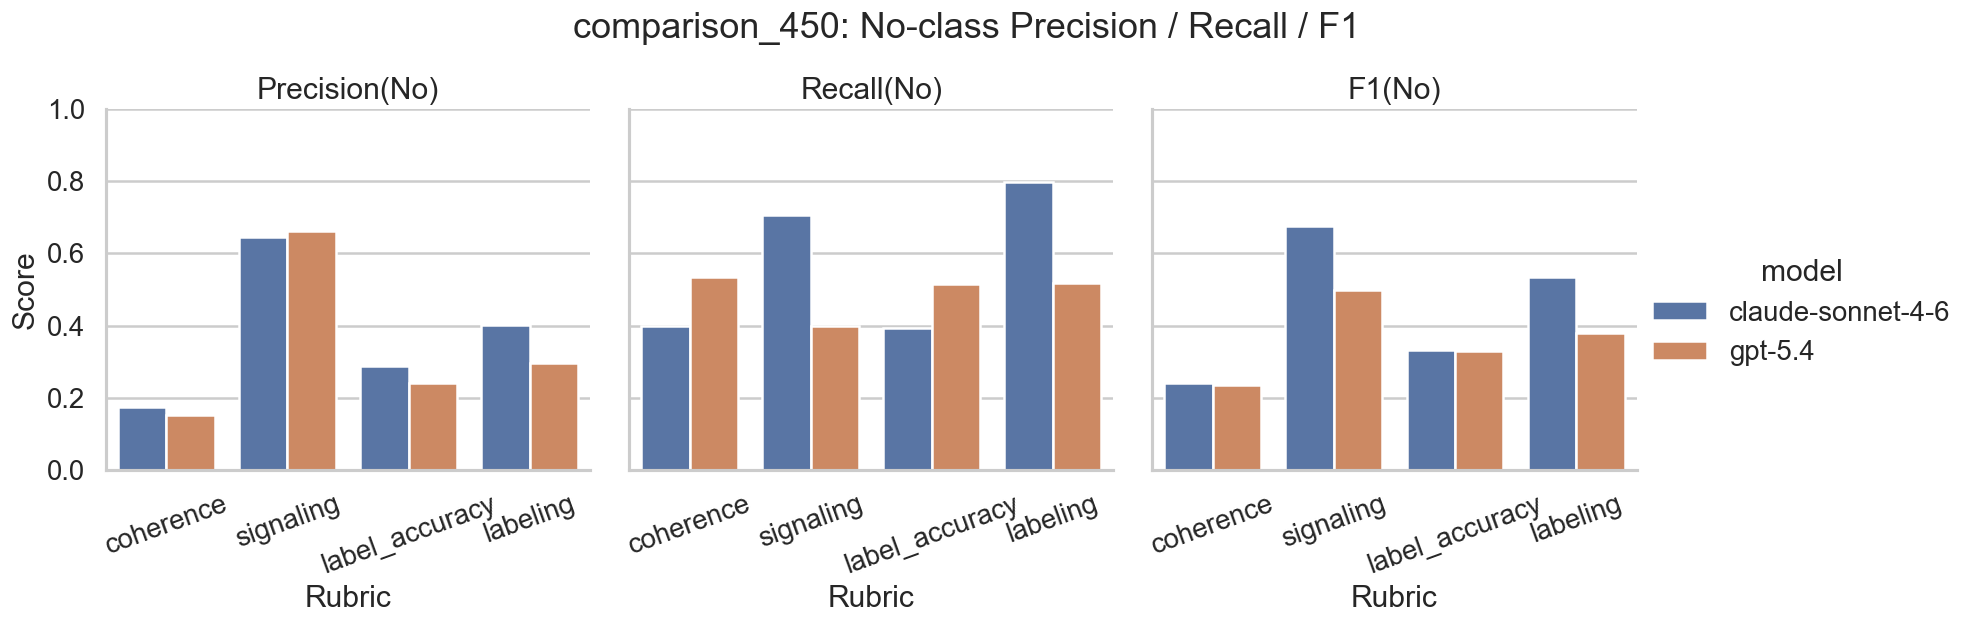

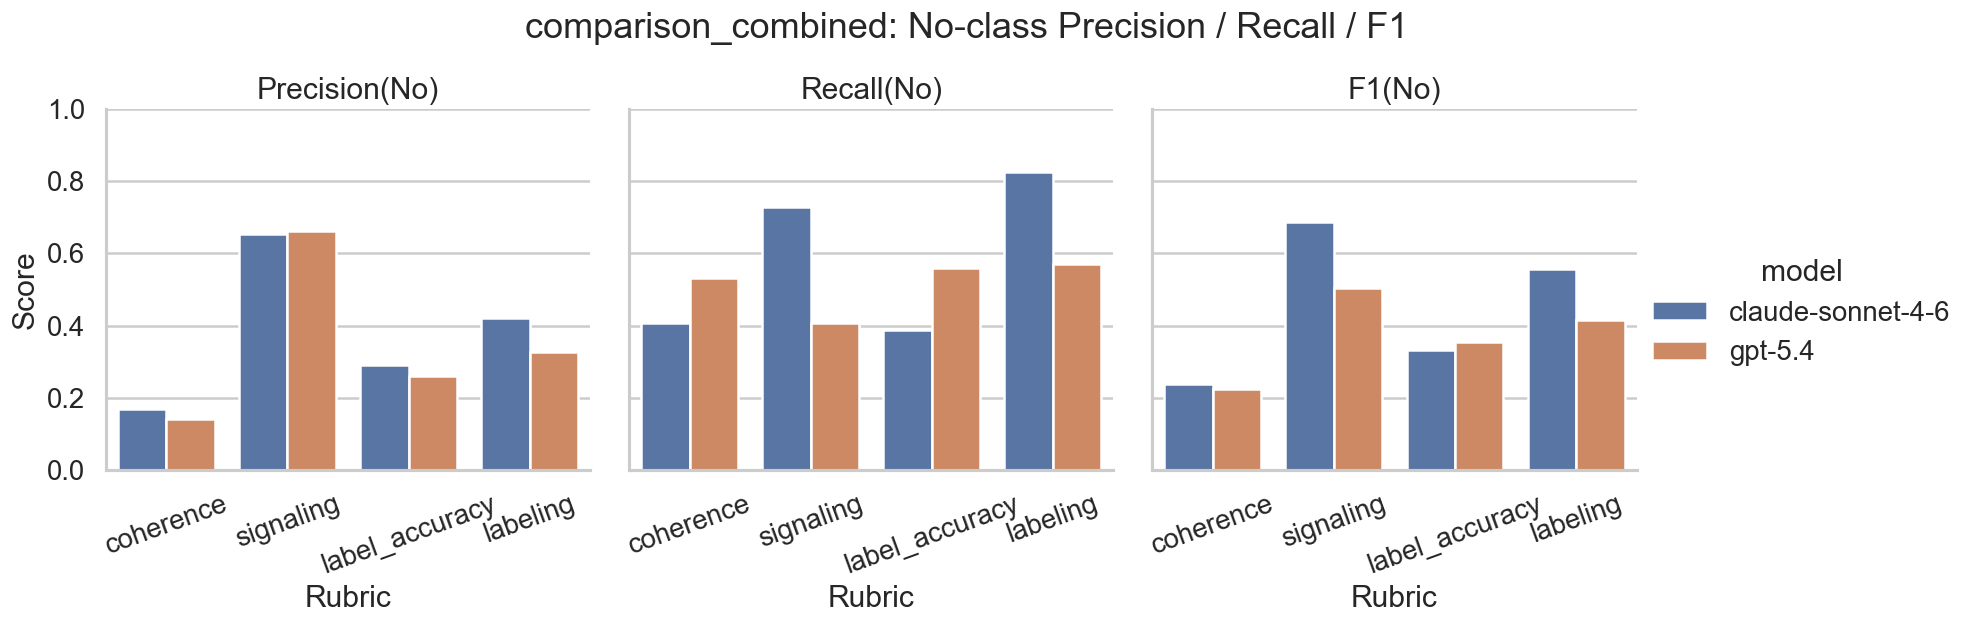

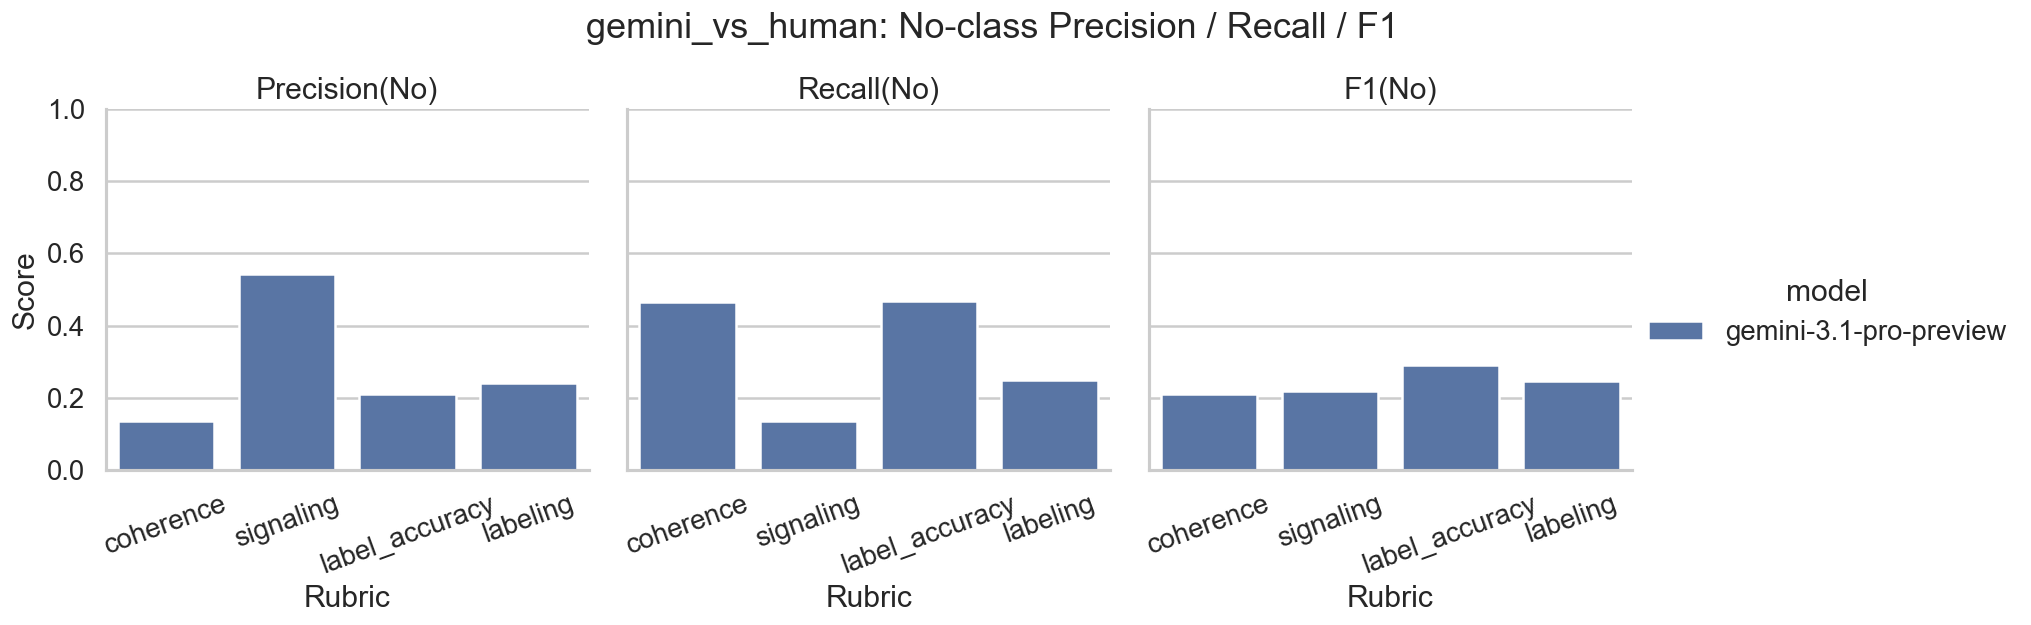

In [56]:
# Graph 1: grouped bars for No-class metrics by rubric/model
plot_df = no_metrics_df.melt(
    id_vars=['dataset', 'model', 'rubric', 'support_no', 'n'],
    value_vars=['precision_no', 'recall_no', 'f1_no'],
    var_name='metric',
    value_name='score',
)

plot_df['metric'] = plot_df['metric'].map({
    'precision_no': 'Precision(No)',
    'recall_no': 'Recall(No)',
    'f1_no': 'F1(No)',
})

for ds in plot_df['dataset'].unique():
    ds_df = plot_df[plot_df['dataset'] == ds]
    g = sns.catplot(
        data=ds_df,
        x='rubric', y='score', hue='model', col='metric',
        kind='bar', height=4.5, aspect=1.05, sharey=True,
    )
    g.set_titles('{col_name}')
    g.set_axis_labels('Rubric', 'Score')
    g.set(ylim=(0, 1.0))
    g.fig.suptitle(f'{ds}: No-class Precision / Recall / F1', y=1.06)
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=20)
    plt.show()


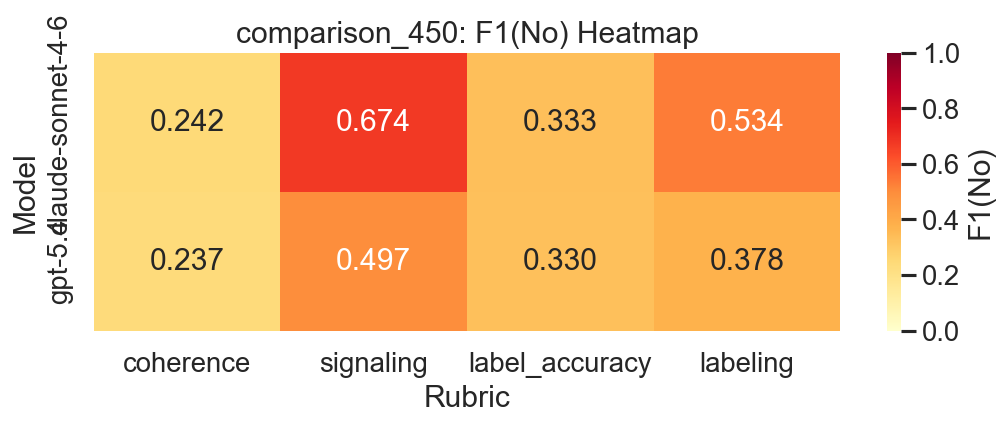

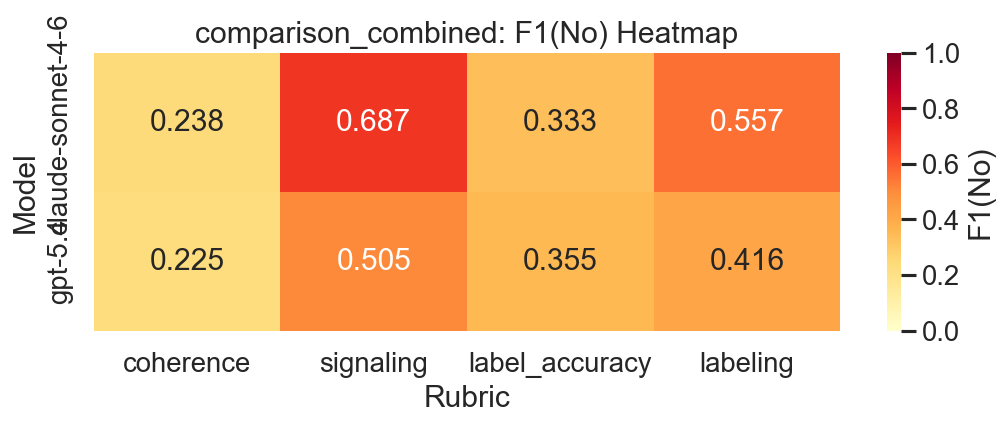

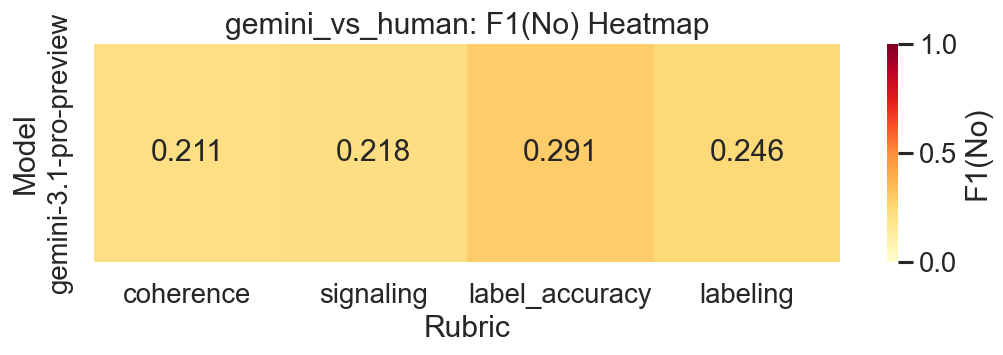

In [16]:
# Graph 2: heatmap of F1(No) for fast comparison
for ds in no_metrics_df['dataset'].unique():
    pivot = (
        no_metrics_df[no_metrics_df['dataset'] == ds]
        .pivot(index='model', columns='rubric', values='f1_no')
        .reindex(columns=RUBRICS)
    )

    plt.figure(figsize=(9, 2.8 + 0.5 * len(pivot.index)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.3f',
        vmin=0,
        vmax=1,
        cmap='YlOrRd',
        cbar_kws={'label': 'F1(No)'},
    )
    plt.title(f'{ds}: F1(No) Heatmap')
    plt.xlabel('Rubric')
    plt.ylabel('Model')
    plt.tight_layout()
    plt.show()


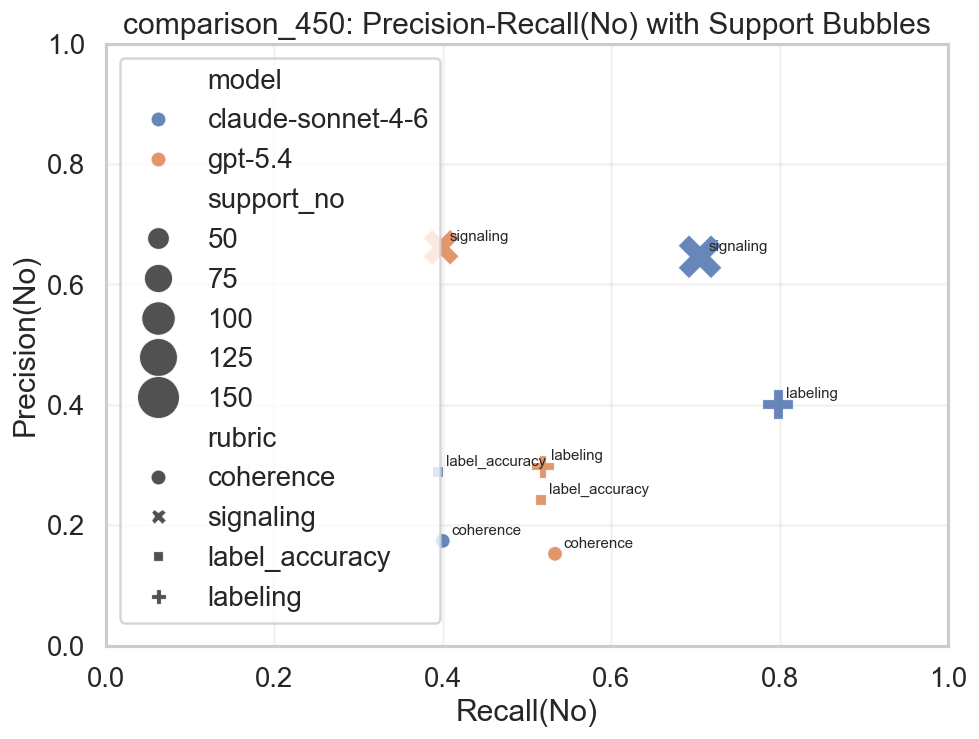

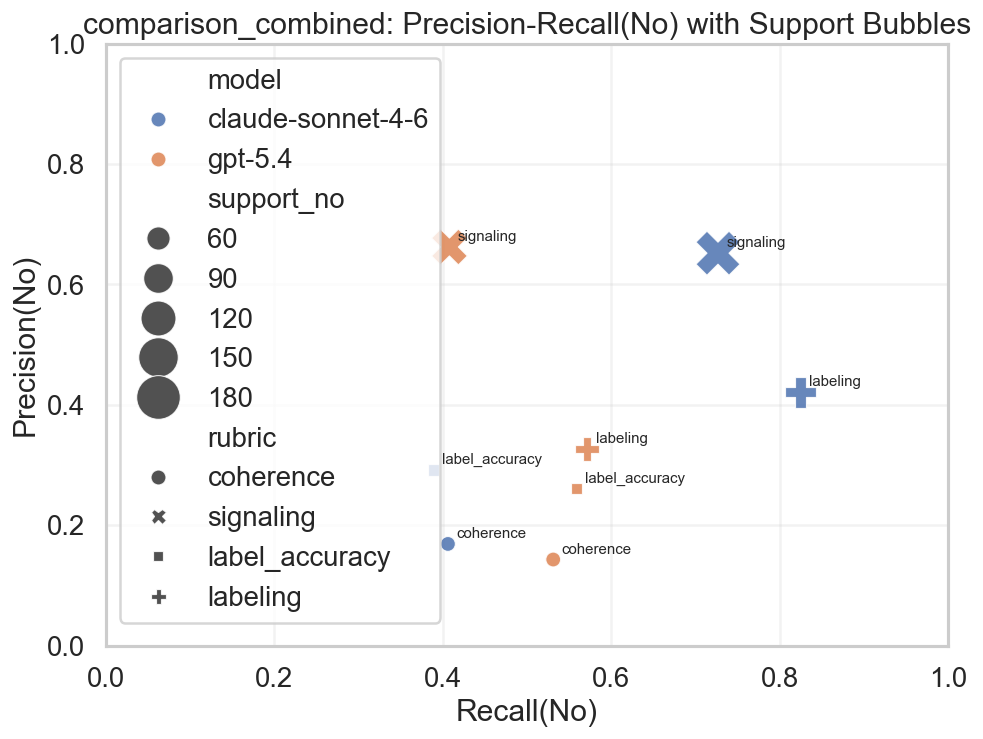

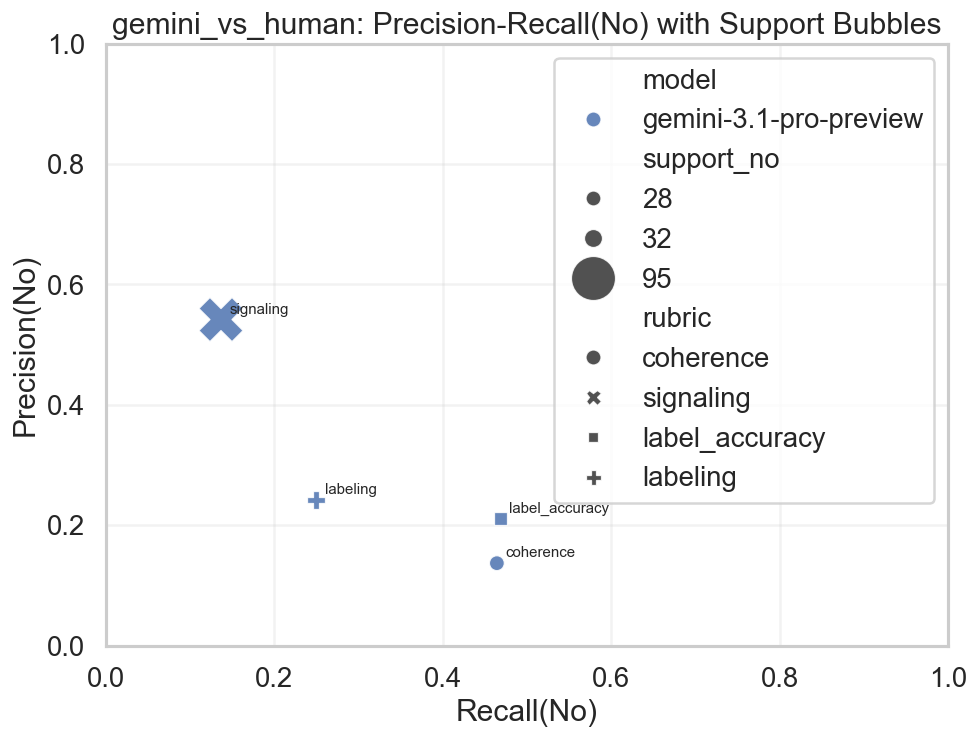

In [17]:
# Graph 3: precision-recall tradeoff with No-support as bubble size
for ds in no_metrics_df['dataset'].unique():
    ds_df = no_metrics_df[no_metrics_df['dataset'] == ds].copy()

    plt.figure(figsize=(8.5, 6.5))
    ax = sns.scatterplot(
        data=ds_df,
        x='recall_no', y='precision_no',
        hue='model', style='rubric',
        size='support_no', sizes=(80, 700),
        alpha=0.85,
    )

    for _, r in ds_df.iterrows():
        ax.text(
            r['recall_no'] + 0.01,
            r['precision_no'] + 0.01,
            r['rubric'],
            fontsize=9,
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Recall(No)')
    ax.set_ylabel('Precision(No)')
    ax.set_title(f'{ds}: Precision-Recall(No) with Support Bubbles')
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


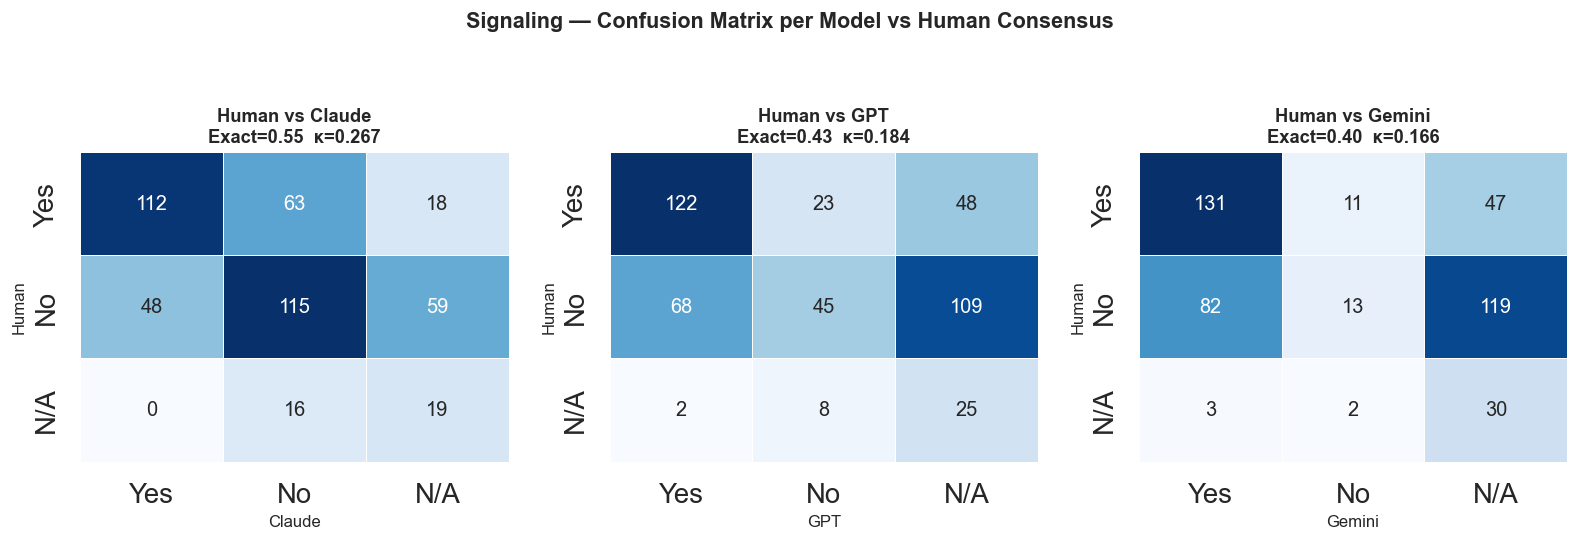

Saved: analysis_plots/signaling_per_model_confusion_matrices.png
Saved: analysis_plots/signaling_per_model_confusion_matrices.svg


In [18]:
# ── Per-model confusion matrices: Signaling dimension only ───────────────────
DIM = "signaling"

MODELS_INFO = [
    ("claude-sonnet-4-6",      "Claude"),
    ("gpt-5.4",                "GPT"),
    ("gemini-3.1-pro-preview", "Gemini"),
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))

for ax, (model_key, model_label) in zip(axes, MODELS_INFO):
    model_data = llm_long[
        (llm_long["model"] == model_key) & (llm_long["dimension"] == DIM)
    ].rename(columns={"value": "model_value"})

    human_data = human_consensus[
        human_consensus["dimension"] == DIM
    ].rename(columns={"value": "human_value"})

    merged = human_data.merge(
        model_data[["diagram_id", "model_value"]], on="diagram_id", how="inner"
    )
    merged = merged[
        merged["human_value"].isin(LABEL_ORDER) & merged["model_value"].isin(LABEL_ORDER)
    ]

    ct = pd.crosstab(
        pd.Categorical(merged["human_value"], categories=LABEL_ORDER),
        pd.Categorical(merged["model_value"], categories=LABEL_ORDER),
        rownames=["Human"],
        colnames=[model_label],
    ).reindex(index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0)

    sns.heatmap(
        ct, annot=True, fmt="d", cmap="Blues",
        linewidths=0.5, cbar=False, ax=ax,
        annot_kws={"size": 12},
    )
    exact = (merged["human_value"] == merged["model_value"]).mean()
    kap = cohens_kappa(
        merged["human_value"].tolist(), merged["model_value"].tolist(), LABEL_ORDER
    )
    ax.set_title(
        f"Human vs {model_label}\nExact={exact:.2f}  κ={kap:.3f}",
        fontsize=11, fontweight="bold",
    )
    ax.set_xlabel(model_label, fontsize=10)
    ax.set_ylabel("Human", fontsize=10)

fig.suptitle(
    "Signaling — Confusion Matrix per Model vs Human Consensus",
    fontsize=13, fontweight="bold", y=1.02,
)
fig.tight_layout()
savefig(fig, PLOT_DIR / "signaling_per_model_confusion_matrices.png")
savefig(fig, PLOT_DIR / "signaling_per_model_confusion_matrices.svg")


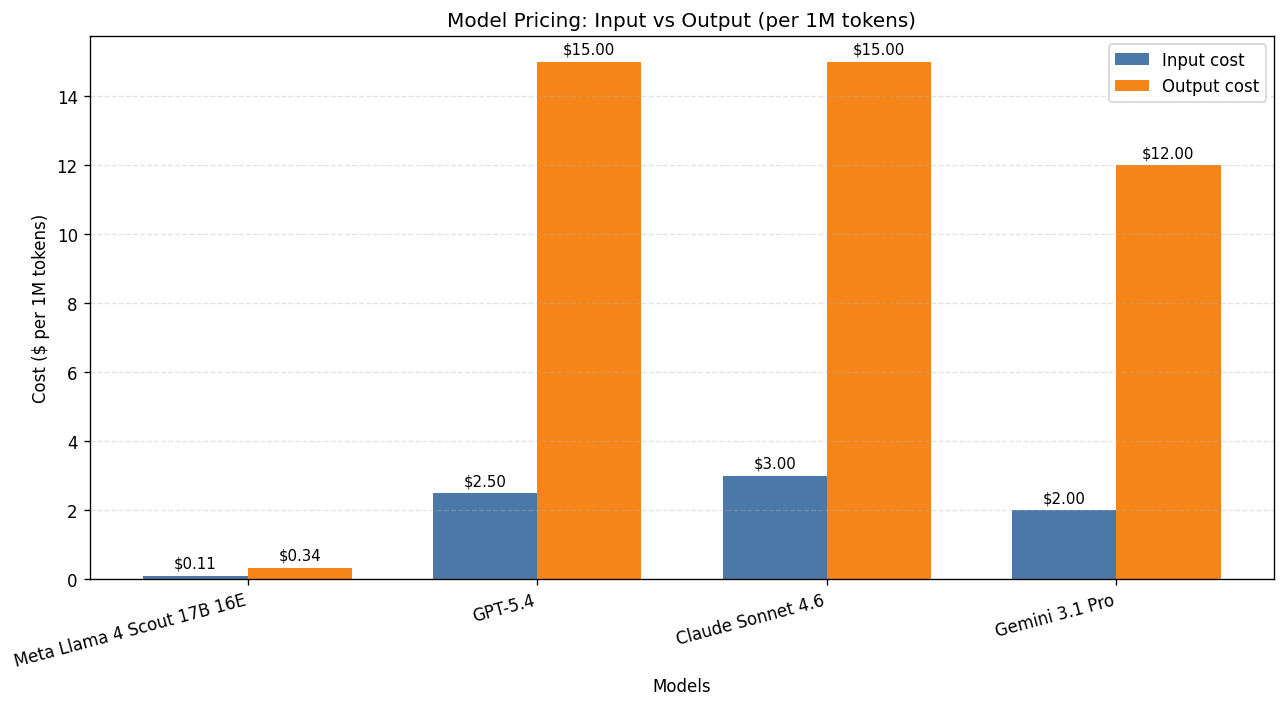

In [10]:
# Grouped bar chart: model pricing per 1M tokens
import numpy as np
import matplotlib.pyplot as plt

models = [
    "Meta Llama 4 Scout 17B 16E",
    "GPT-5.4",
    "Claude Sonnet 4.6",
    "Gemini 3.1 Pro",
]
input_costs = [0.11, 2.50, 3.00, 2.00]
output_costs = [0.34, 15.00, 15.00, 12.00]

x = np.arange(len(models))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))
input_bars = ax.bar(x - width / 2, input_costs, width, label="Input cost", color="#4C78A8")
output_bars = ax.bar(x + width / 2, output_costs, width, label="Output cost", color="#F58518")

ax.set_xlabel("Models")
ax.set_ylabel("Cost ($ per 1M tokens)")
ax.set_title("Model Pricing: Input vs Output (per 1M tokens)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.35)

for bars in (input_bars, output_bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"${height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.tight_layout()
plt.show()
